# Examining Garmin Data

##Questions about data source

### Motivation

For what purpose was this dataset created? Was there a specific task or gap it was meant to address?
* This dataset was created in large part to provide health and training data for those with Garmin watches, typically runners or cyclists (although I will only be working with general data and running-specific data)

Who funded the creation of the dataset?
* The Garmin company funded the creation of this dataset

### Composition

Does the dataset contain all possible instances, or is it a sample? If a sample—is it representative? What might be missing?
* It contains all data that my watches have collected since early September 2021, including 15,785 files of highly detailed sleep, activity, monitoring, and other data, plus 15 files of general sleep data,

Are there any errors, sources of noise, or redundancies in the dataset?
* TO DO

Does it identify any subpopulations (e.g., by age, gender, geography)? How are they identified?
* No, the data with which I am working is entirely about myself

### Collection Process

Who was involved in collecting the data, and how were they compensated?
* I created and collected the data using my Garmin watch, and I was compensated with an increased fitness.

Did the individuals whose data was collected consent to its collection and use?
* Yes, I consent to its collection and use.

### Uses

Are there tasks for which this dataset should NOT be used?
* This dataset should not be used for questions unrelated to my running or other health questions that this dataset does not cover (for example, this dataset should not be used to answer questions involving my caloric intake or hydration).

## Things I might do

Create a heatmap (take that, Strava premium!)

Compare data about training cycles to race times

See how sleep in the days/week(s)/month before a race correlates with my race times relative to other races (sleep data is somewhat inaccurate however, based on instances where I know I went to bed at a certain time but my watch thinks I went to bed earlier or later)

## Notes

First timestamp: 2021-09-06 00:15:42.598

DI-Connect-Wellness:
98572192_fitnessAgeData.json contains "biometricVo2Max", based on "rhr" (also contained)

98572192_userBioMetrics.json contains "vo2MaxRunning"

Sleep_data: contains sleep data, but different watches have different data it seems, and the same variables ("deepSleepSeconds", for example) seem to have different meanings for the different watches. 2024-05-19_2024-08-27_98572192_sleepData.json is all old data except for last element; older times have old form of data while newer times have new form of data. Oldest date of new form: "calendarDate": "2024-08-26"

The UDS (User Daily Statistics?) files contain "minHeartRate" and "minAvgHeartRate"; the latter is typically higher (probably averaged over a few minutes while the former is a brief minimum). Some days have more data than others.

In UDS files: "totalDistanceMeters" seems to be calculated as "totalSteps" * [strideLength] (I don't know where that variable is stored right now, but it's in a different file path); the default stride length used to be 1 meter per step but I changed it at some point. Regardless, "totalDistanceMeters" is probably innaccurate given how different my stride length is when running versus when walking. I could calculate that by accounting for both my running distance and steps, but that's a lot of work and probably wouldn't be that helpful

DI-Connect-Fitness: "legomyeyeball@gmail.com_1001_summarizedActivities.json" and "legomyeyeball@gmail.com_0_summarizedActivities.json" contain data on all of my activities. Averaged data may be considerably off due to my not recording splits properly/at all some times. Also, there are some days where I recorded my WU and CD separately from the workout, and others where I did not. Furthermore, there are times when I just don't mark a change in what I'm doing at all (like not even starting a new lap when I do wickets).


DI-Connect-Uploaded-Files: All are .fit filetype. At least for files of when I'm asleep, the "data" column of the "event" section appears to be the number of minutes since the last datapoint. Sleep files also contain detailed respiration rate, stress, and body battery data, at least while I've had my newer watch.

The watch used to collect data is shown under File ID -> product info -> "fr35" or "fr55"; or under Device Info -> product info -> "fr35" or "fr55". The File ID path seems more useful since that contains the file type as well (see following).

File types (stored in the File ID section):
* metrics (no useful info?)
* sleep (sometimes useful info? --can be a file containing no timestamps while I am tagged as asleep)
  * I don't think these are decoded properly--I found a file spanning 8 hours, 10 kilobytes, and it shows 5 rows of data (none of it while I'm asleep)
* monitoring b
  * Monitoring section:
  * contains various activities (sedentary, walking, generic, running, etc.) and cumulative data on steps ("cycles"), hr, intensity, and timestamps (which are confusing; perhaps the "start timestamp" column is in GMT time? it's about 9 hours after the "timestamp" column, but the minutes don't quite line up properly)
  * each file is on approximately 4 hours of data
  * data is cumulative for the day, and may/will be added to data collected in a different file
  * last few rows seem to summarize all data in the file by activity type
  * "duration min" column seems to mimic the "timestamp" column rather than convey the duration in minutes as it claims to
  * Event section:
  * contains events (such as auto activity detect or 41 (seems like an error code) ), activity type (aligns with activity type from the Monitoring section), data (length of activity in minutes?), and "timestamp" and "start timestamp" columns that do not align ("timestamp" appears to be 15 minutes after the detected activity ends, per the "start timestamp" and "data" columns)
  * seems to be less useful for old watch
  * Stress Level section:
  * contains stress level value (mostly scaled 1-100, but some values of -2), timestamps, and body battery (scaled 1-100), all measured every minute
  * Respiration rate section:
  * contains timestamps and respiration rate data (meaningful except for values of -1)
* file type of "41" (seems to be some sort of error code, at least for newer watch)
* activity
  * User Metrics:
  * timestamp, vo2 max, age, height, weight, gender, max hr, remaining recovery time
  * Event:
  * timestamps, event (timer, session), event type (start, stop all, stop disable all, etc.)
  * Sport:
  * sport (running, presumably walking and swimming or something similar as well, but both considerably less often than running), sub sport (generic)
  * Record:
  * data every second
  * timestamp, position lat, position long, heart rate, cadence (single leg), distance, enhanced speed
  * Lap:
  * many things, including time, distance, strides, hr, cadence, and lap trigger (distance, session end)

The hydration files don't contain much useful information beyond
"estimatedSweatLossInML", which appears to be calculated as floor(("duration" in ms)), but it does appear to include the date of every activity I've recorded, which may be useful for filtering purposes.

# Separate the files based on type

In [ ]:
# connect to drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
!pip install fitparse pandas      #needed to parse activity and monitoring data
from fitparse import FitFile
import os                         #needed to refer to folders

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fitparse: filename=fitparse-1.2.0-py3-none-any.whl size=68214 sha256=d17608f06dbf838342932c4a1c4e5e8f1588f53f6811859b5a9249b5dbaaa15a
  Stored in directory: /root/.cache/pip/wheels/70/74/f4/07ba357f689c8c76c09a5c6c399831b0cb3452dcc7703f304c
Successfully built fitparse


Time to try converting a set of 16 files (it took me 25 minutes just to upload the files to google drive and I am not about to try uploading all of the files to colab at once unless I think it will work, and I have low hopes for the first few tries because it's coding and I've never tried this before).

In [ ]:
folder_path_test_16 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/16 test files (duplicates)'

test_counter = 0                              # to count the number of files the test run iterates through

for filename in os.listdir(folder_path_test_16):
  if filename.endswith('.fit'):               # why not double check file type in the test run
    test_counter = test_counter + 1           # add one to the test counter if it found the file

print(test_counter)

16


A miracle! It looks like it iterated through all of the files! Now I want to try opening them to see if I can access the type of data it stores, which I know is located in a "File ID" section based on opening some files in a file converter.

In [ ]:
test_counter = 0    # used to differentiate files

# return all of the messages in the test set
for filename in os.listdir(folder_path_test_16):
  full_path_test_16 = os.path.join(folder_path_test_16, filename)
  fitfile = FitFile(full_path_test_16)

  # print a break line for readability
  print("")
  #iterate through all messages and print them
  for message in fitfile.get_messages():
    print(f"File {test_counter}:", message)

  #increment the counter
  test_counter = test_counter + 1


File 0: file_id (#0)
File 0: device_info (#23)
File 0: software (#35)
File 0: monitoring_info (#103)
File 0: monitoring (#55)
File 0: monitoring (#55)
File 0: unknown_24 (#24)
File 0: unknown_24 (#24)
File 0: unknown_24 (#24)
File 0: monitoring (#55)
File 0: monitoring (#55)
File 0: monitoring (#55)
File 0: unknown_211 (#211)

File 1: file_id (#0)
File 1: device_info (#23)
File 1: software (#35)
File 1: monitoring_info (#103)
File 1: monitoring (#55)
File 1: monitoring (#55)
File 1: monitoring (#55)
File 1: monitoring (#55)
File 1: monitoring (#55)
File 1: monitoring (#55)
File 1: monitoring (#55)
File 1: monitoring (#55)
File 1: monitoring (#55)
File 1: monitoring (#55)
File 1: monitoring (#55)

File 2: file_id (#0)
File 2: device_info (#23)
File 2: software (#35)
File 2: monitoring_info (#103)
File 2: monitoring (#55)
File 2: unknown_211 (#211)
File 2: monitoring (#55)
File 2: unknown_211 (#211)

File 3: file_id (#0)
File 3: device_info (#23)
File 3: software (#35)
File 3: monitorin

Side-quest: this shows that there are 5 "monitoring" messages in the first file, while the online converter has 11 rows of data with some blanks and a couple of duplicate timestamps, so I want to figure out what's causing this difference. To do that, I want to see what the actual messages are.

In [ ]:
test_counter = 0    # used to differentiate files

# parse all of the files in the test set
for filename in os.listdir(folder_path_test_16):
  full_path_test_16 = os.path.join(folder_path_test_16, filename)
  fitfile = FitFile(full_path_test_16)

  # print a break line and file name for readability
  print("")
  print(f"File {test_counter}")
  #iterate through all monitoring messages and print them
  for msg in fitfile.get_messages('monitoring'):
    data = {f.name: f.value for f in msg if f.value is not None}
    print(data)

  #increment the counter
  test_counter = test_counter + 1


File 0
{'timestamp': datetime.datetime(2021, 1, 17, 23, 3), 'unknown_37': 0, 'unknown_38': 0}
{'activity_type': 9, 'current_activity_type_intensity': (9,), 'intensity': 0, 'timestamp': datetime.datetime(2021, 1, 17, 23, 3)}
{'heart_rate': 72, 'timestamp_16': 30304}
{'activity_type': 'sedentary', 'current_activity_type_intensity': (72,), 'intensity': 2, 'timestamp': datetime.datetime(2021, 1, 17, 23, 4)}
{'timestamp': datetime.datetime(2021, 1, 17, 23, 4), 'unknown_37': 0, 'unknown_38': 0}

File 1
{'timestamp': datetime.datetime(2021, 1, 17, 22, 16), 'unknown_37': 0, 'unknown_38': 0}
{'activity_type': 'sedentary', 'current_activity_type_intensity': (8,), 'intensity': 0, 'timestamp': datetime.datetime(2021, 1, 17, 22, 16)}
{'heart_rate': 0, 'timestamp_16': 27484}
{'activity_type': 'sedentary', 'current_activity_type_intensity': (136,), 'intensity': 4, 'timestamp': datetime.datetime(2021, 1, 17, 22, 17)}
{'activity_type': 'sedentary', 'current_activity_type_intensity': (8,), 'intensity':

For whatever reason, the order of the files in the test set folder on my computer that I'm pulling files from when I use the online converter is different (it might have been flipped, as in from A-Z on one end and from Z-A on the other? truly not sure) from that of the folder on Google drive, so that's why the first file has 5 messages listed instead of 11. This shouldn't be a problem (famous last words, I know) since I ought to be able to sort files by date before/after combining them.

Speaking of dates, this subset of files shows something very intriguing. The first file, File 0, has a date of just before midnight at the end of 2016 (23:59 on 12/31/2016), and there is another file (File 14) started at midnight at the very beginning of 2017 (00:00 on 1/1/2017), and two brief activities on January 17, 2017 (Files 9 and 15), despite me not getting my watch until early September of 2021 (I'd guess September 6th, based on these timestamps). My best guess is that this data is from some testing period, although the existence of heart rate data for File 9 makes me unsure (unless they were testing the heart-rate monitor). Regardless, I'll just drop files from before 9/6/2021 when I work with the whole set. (Side note: based on checking a different file in the online converter against these monitoring messages, taking care to check the correct one, the monitoring messages seem to be using UTC time instead of local time, so I'd like to take that into account at some point.)

Now I actually want to see the File ID messages, so I'm going to print them.

In [ ]:
test_counter = 0    # used to differentiate files

# parse all of the files in the test set
for filename in os.listdir(folder_path_test_16):
  full_path_test_16 = os.path.join(folder_path_test_16, filename)
  fitfile = FitFile(full_path_test_16)

  # print a break line and file name for readability
  print("")
  print(f"File {test_counter}")
  #iterate through all file_id messages and print them
  for msg in fitfile.get_messages('file_id'):
    data = {f.name: f.value for f in msg if f.value is not None}
    print(data)

  #increment the counter
  test_counter = test_counter + 1


File 0
{'garmin_product': 2503, 'manufacturer': 'garmin', 'number': 2, 'serial_number': 3360854617, 'time_created': datetime.datetime(2021, 1, 17, 23, 3), 'type': 'monitoring_b'}

File 1
{'garmin_product': 2503, 'manufacturer': 'garmin', 'number': 1, 'serial_number': 3360854617, 'time_created': datetime.datetime(2021, 1, 17, 22, 16), 'type': 'monitoring_b'}

File 2
{'garmin_product': 2503, 'manufacturer': 'garmin', 'number': 12, 'serial_number': 3360854617, 'time_created': datetime.datetime(2021, 9, 6, 0, 20), 'type': 'monitoring_b'}

File 3
{'garmin_product': 2503, 'manufacturer': 'garmin', 'number': 14, 'serial_number': 3360854617, 'time_created': datetime.datetime(2021, 9, 6, 0, 21), 'type': 'monitoring_b'}

File 4
{'garmin_product': 2503, 'manufacturer': 'garmin', 'number': 7, 'serial_number': 3360854617, 'time_created': datetime.datetime(2021, 9, 6, 0, 19), 'type': 'monitoring_b'}

File 5
{'garmin_product': 2503, 'manufacturer': 'garmin', 'number': 15, 'serial_number': 3360854617

These ones happen to all be of 'type' 'monitoring_b', but the 'type' key should indicate other varieties at times. Now I want to access just the value for the 'type' key.

In [ ]:
test_counter = 0    # used to differentiate files

# parse all of the files in the test set
for filename in os.listdir(folder_path_test_16):
  full_path_test_16 = os.path.join(folder_path_test_16, filename)
  fitfile = FitFile(full_path_test_16)

  # print a break line for readability
  print("")
  #iterate through all file_id messages and print the value for the 'type' key
  for msg in fitfile.get_messages('file_id'):
    for f in msg:
      if (f.name == 'type'):
        data = f.value
  print(f"File {test_counter} type:", data)

  #increment the counter
  test_counter = test_counter + 1


File 0 type: monitoring_b

File 1 type: monitoring_b

File 2 type: monitoring_b

File 3 type: monitoring_b

File 4 type: monitoring_b

File 5 type: monitoring_b

File 6 type: monitoring_b

File 7 type: monitoring_b

File 8 type: monitoring_b

File 9 type: monitoring_b

File 10 type: monitoring_b

File 11 type: monitoring_b

File 12 type: monitoring_b

File 13 type: monitoring_b

File 14 type: monitoring_b

File 15 type: monitoring_b


Yay, now I have the type of each file. I want to look at more files to get more types now so that I can sort files by type.

In [ ]:
folder_path_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)'

test_counter = 0    # used to differentiate files

# return all of the messages in the test set
for filename in os.listdir(folder_path_test_256):
  full_path_test_256 = os.path.join(folder_path_test_256, filename)
  fitfile = FitFile(full_path_test_256)

  #iterate through all file_id messages and print the value for the 'type' key
  for msg in fitfile.get_messages('file_id'):
    for f in msg:
      if (f.name == 'type'):
        data = f.value
  print(f"File {test_counter} type:", data)

  #increment the counter
  test_counter = test_counter + 1

IsADirectoryError: [Errno 21] Is a directory: '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)/monitoring_b'

I'd have thought that I would have at least a sleep or metrics file in the first 256 files, but I guess metrics files are less common than I thought, and maybe I didn't wear my watch to bed at first. Oh well. I'm going to try grouping files by type now and putting them into new sub folders. The first step of this is creating a dataframe of the file name (or better yet, the full file path) and the type of the file.

In [ ]:
folder_path_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)'

#create empty set of rows that files will get added to
rows = []

# parse all of the files in the test set
for filename in os.listdir(folder_path_test_256):
  full_path_test_256 = os.path.join(folder_path_test_256, filename)
  fitfile = FitFile(full_path_test_256)

  #iterate through all file_id messages and print the value for the 'type' key
  for msg in fitfile.get_messages('file_id'):
    filetype = msg.get_value('type')

  rows.append({'file_name': filename, 'file_type': filetype})

df_test_256_file_type = pd.DataFrame(rows)
df_test_256_file_type

That works, but now that I think about it, it feels like I can cut out the middleman of the dataframes and just search directly for the type of the files and then create folders based on that instead of throwing it into a dataframe first. So, now I want to make folders for the different types of files and then move matching ones into them without creating a dataframe. Having these in actual folders will help me (hopefully) with other tasks that I haven't thought of yet. At the very least, if I decide I only want to work with certain types of files, then I can only import those from my drive instead of jumping through all of these hoops.

In [ ]:
import shutil       # needed to move files

folder_path_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)'

# define a function to access file type
def get_file_type(filepath):
  fitfile = FitFile(filepath)
  for msg in fitfile.get_messages('file_id'):
    return msg.get_value('type')

# apply that function to each file in the test set
for filename in os.listdir(folder_path_test_256):
  if filename.endswith('.fit'):
    start_path_test_256 = os.path.join(folder_path_test_256, filename)
    file_type = get_file_type(start_path_test_256)

    # create new folders if needed
    sorted_folder_test_256 = os.path.join(folder_path_test_256, file_type)
    os.makedirs(sorted_folder_test_256, exist_ok = True)

    # move files to sorted folders
    sorted_path_test_256 = os.path.join(sorted_folder_test_256, filename)
    shutil.move(start_path_test_256, sorted_path_test_256)

Looking at the folder system, this appears to have worked! Now that files are sorted, I want to start making dataframes so I can actually work with the data.

# Putting files into dataframes

## Activity files

In [ ]:
activity_folder_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)/activity'

#create empty set of rows that files will get added to
rows = []

# parse all of the files in the test set of type activity
for filename in os.listdir(activity_folder_test_256):
  full_path_test_256 = os.path.join(activity_folder_test_256, filename)
  fitfile = FitFile(full_path_test_256)

  #iterate through all messages and add them to rows
  for messages in fitfile.get_messages():
    for msg in messages:
      rows.append({msg.name: msg.value})

df_test_256_activities = pd.DataFrame(rows)
df_test_256_activities

Well, it's in a dataframe, but there's a bajillion NaN and NaT values, it seems like each row only contains one (maybe multiple in some instances?) meaningful values, and there's who knows how many "unknown" columns that contain information I probably don't need and definitely don't understand. I don't know what to do about the NaN values right now, but I can at least drop (or rather, never create) the "unknown" columns and drop the NaN rows. I also might need to sort the activities by time before adding them to the dataframe, but I'll address that issue later.

In [ ]:
activity_folder_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)/activity'

#create empty set of rows that files will get added to
rows = []

# parse all of the files in the test set of type activity
for filename in os.listdir(activity_folder_test_256):
  full_path_test_256 = os.path.join(activity_folder_test_256, filename)
  fitfile = FitFile(full_path_test_256)

  #iterate through all messages and add them to rows
  for messages in fitfile.get_messages():
    for msg in messages:
      if 'unknown' not in msg.name:          # exclude the "unknown_0" type of columns
        data = {msg.name: msg.value}
        if not any(data.values()):           # exclude empty rows
          continue
        rows.append({msg.name: msg.value})

#show all columns
pd.set_option('display.max_columns', None)

df_test_256_activities = pd.DataFrame(rows)
df_test_256_activities

That should only have usable information, but much of it is stuff I don't need, like the manufacturer, serial number, number of laps, and other things, so I'm going to go ahead and drop (or rather not add) columns I don't want.

The first step of that is finding the names of all the variables I want. I can see names for most things in the online converter, but I don't know what the actual names in the messages are, so I'm going to try printing the key/value pairs for each new key.

In [ ]:
activity_folder_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)/activity'

# create list to add unique messages to
unique_msgs = []
# create list to add unique message paths to
unique_message_msgs = []

# parse all of the files in the test set of type activity
for filename in os.listdir(activity_folder_test_256):
  full_path_test_256 = os.path.join(activity_folder_test_256, filename)
  fitfile = FitFile(full_path_test_256)

  # iterate through all messages and print unique message/key combinations
  for messages in fitfile.get_messages():
    for msg in messages:
      if msg.name not in unique_msgs and 'unknown' not in msg.name:        # exclude the keys that have unreadable names
        unique_msgs.append(msg.name)
        #print(msg.name)
      if f'{messages}: {msg.name}' not in unique_message_msgs and 'unknown' not in msg.name:      # exclude unreadable keys
        unique_message_msgs.append(f'{messages}: {msg.name}')
        print(f'{messages}: {msg.name}')

I now have two sets of strings, one with all unique keys and one with all unique message/key combinations. These will help me filter what I do and don't want to keep. Now I want to create two sets of strings, one that contains just the messages I want keys from, and another that contains just the keys I want from those messages. I will be using the online file converter to help me understand what this data looks like.

But first, one key that I am very keen on having is something along the lines of 'vo2_max' in the message 'user_id', and I don't see that here, presumably because I either hadn't set up my profile yet or there wasn't enough data to calculate my vo2_max, so I am going to scale up the test set yet again, run the code to sort by file type, and then retrieve the unique keys and message/key combinations.

In [ ]:
# move files into folders based on type
folder_path_test_512 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/512 test files (duplicates)'

# define a function to access file type
def get_file_type(filepath):
  fitfile = FitFile(filepath)
  for msg in fitfile.get_messages('file_id'):
    return msg.get_value('type')

# apply that function to each file in the test set
for filename in os.listdir(folder_path_test_512):
  if filename.endswith('.fit'):
    start_path_test_512 = os.path.join(folder_path_test_512, filename)
    file_type = get_file_type(start_path_test_512)

    # create new folders if needed
    sorted_folder_test_512 = os.path.join(folder_path_test_512, file_type)
    os.makedirs(sorted_folder_test_512, exist_ok = True)

    # move files to sorted folders
    sorted_path_test_512 = os.path.join(sorted_folder_test_512, filename)
    shutil.move(start_path_test_512, sorted_path_test_512)


# retrieve unique keys and message/key combinations

activity_folder_test_512 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/512 test files (duplicates)/activity'

# create list to add unique messages to
unique_msgs = []
# create list to add unique message paths to
unique_message_msgs = []

# parse all of the files in the test set of type activity
for filename in os.listdir(activity_folder_test_512):
  full_path_test_512 = os.path.join(activity_folder_test_512, filename)
  fitfile = FitFile(full_path_test_512)

  # iterate through all messages and print unique message/key combinations
  for messages in fitfile.get_messages():
    for msg in messages:
      if msg.name not in unique_msgs and 'unknown' not in msg.name:        # exclude the keys that have unreadable names
        unique_msgs.append(msg.name)
        #print(msg.name)
      if f'{messages}: {msg.name}' not in unique_message_msgs and 'unknown' not in msg.name:      # exclude unreadable keys
        unique_message_msgs.append(f'{messages}: {msg.name}')
        print(f'{messages}: {msg.name}')

I still don't see either of those, and I know that the file converter produced it from at least one file in this set, so I'm going to try using a different parser (fitdecode) that may have 'user_id' and/or 'vo2_max', and I'm also going to go back the 256-file test folder to speed things up.

In [ ]:
!pip install fitdecode
import fitdecode      # lower-level, better maintained parser that may be able to parse developer fields

# access all of the files in the test set of type activity
activity_folder_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)/activity'
for filename in os.listdir(activity_folder_test_256):
  full_path_test_256 = os.path.join(activity_folder_test_256, filename)

# create list to add unique messages to
unique_msgs = []
# create list to add unique message paths to
unique_msg_fields = []

# iterate through all messages and fields
with fitdecode.FitReader(full_path_test_256) as fit:
  for frame in fit:
    if isinstance(frame, fitdecode.FitDataMessage):
      msg_name = frame.name

      for field in frame.fields:
        field_name = field.name
        #value = field.value

        # collect unique messages and message-field combinations
        if msg_name not in unique_msgs:
          unique_msgs.append(msg_name)
          #print(msg_name)
        if f'{msg_name}: {field_name}' not in unique_msg_fields and 'unknown' not in field_name:      # exclude unreadable keys
          unique_msg_fields.append(f'{msg_name}: {field_name}')
          print(f'{msg_name}: {field_name}')

Well, this parser didn't find them either, but it seems to be about as useful but excludes the (#0) aspect of the messages while also keeping things a little bit more organized (at least in the printout), so I'm going to stick to this one now. As for the online converter finding user metrics and vo2 max, I can only guess that it either calculated them itself or somehow found more data in the file than I can (looking more closely at the online converter, I see a little info button that says the "User Metrics" category is undocumented data). Regardless, I should have vo2 max information stored in a different set of files, so I can just use that if need be.

Now, back to creating the filter sets of fields and messages!

In [ ]:
# create lists of messages and fields to include as df columns
wanted_msgs = ['file_id', 'record', 'session']

wanted_fields = ['garmin_product', 'timestamp', 'position_lat', 'position_long', 'distance', 'enhanced_speed',
                 'heart_rate', 'cadence', 'total_distance', 'total_strides', 'enhanced_avg_speed', 'sport',
                 'avg_heart_rate', 'max_heart_rate', 'avg_running_cadence', 'max_running_cadence']

activity_folder_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)/activity'

# create empty set of rows that data will get added to
rows = []

# parse all of the files in the test set of type activity
for filename in os.listdir(activity_folder_test_256):
  full_path_test_256 = os.path.join(activity_folder_test_256, filename)
  fitfile = FitFile(full_path_test_256)

  # iterate through all messages and fields
  with fitdecode.FitReader(full_path_test_256) as fit:
    for frame in fit:
      if isinstance(frame, fitdecode.FitDataMessage):
        msg_name = frame.name

        if msg_name in wanted_msgs:     # include wanted message categories only
          for field in frame.fields:
            field_name = field.name

            if field_name in wanted_fields:
              value = field.value
              data = {field_name: value}
              if not any(data.values()):         # exclude empty rows
                continue
              rows.append(data)

# show all columns
pd.set_option('display.max_columns', None)

df_test_256_activities = pd.DataFrame(rows)
df_test_256_activities

I wanted to use "garmin_product" from "file_id" to eventually filter between the two watches I've used, but it only shows "connect" instead of "fr35" or "fr55" (for Forerunner 35 and Forerunner 55, respectively), so I guess I'll just have to manually check what date I got my new watch and filter based off of that, which shouldn't be too difficult since I already know that I got it sometime in August of 2024.

Other than that, the information stored in the dataframe is what I want. The only issue is that it might as well be stored in a list for how compact it isn't. Next step is compacting the information based on timestamp.

In [ ]:
# create lists of messages and fields to include as df columns
wanted_msgs = ['record', 'session']

wanted_fields = ['timestamp', 'position_lat', 'position_long', 'distance', 'enhanced_speed',
                 'heart_rate', 'cadence', 'total_distance', 'total_strides', 'enhanced_avg_speed', 'sport',
                 'avg_heart_rate', 'max_heart_rate', 'avg_running_cadence', 'max_running_cadence']

activity_folder_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)/activity'

# create empty set of rows that data will get added to
rows = []

# create counter for id
i = 0

# initialize a filename_current to compare future files to
filename_current = os.listdir(activity_folder_test_256)[0]

# parse all of the files in the test set of type activity
for filename in os.listdir(activity_folder_test_256):
  full_path_test_256 = os.path.join(activity_folder_test_256, filename)
  fitfile = FitFile(full_path_test_256)

  # iterate through all messages and fields
  with fitdecode.FitReader(full_path_test_256) as fit:
    for frame in fit:
      if isinstance(frame, fitdecode.FitDataMessage):
        msg_name = frame.name

        if msg_name == 'record':              # include record message category only
          row = {}                            # create space for all data corresponding to a single timestamp
          for field in frame.fields:
            field_name = field.name

            if field_name in wanted_fields:
              row[field_name] = field.value

          if row:                             # only append if row has data
            row['filename'] = filename        # include filename to allow traceback and sorting

            # add an id unique to each file
            if filename != filename_current:
              i = i + 1
              filename_current = filename
            row['activity_id'] = i

            rows.append(row)

# show all columns
pd.set_option('display.max_columns', None)

# create df
df_test_256_activities_record = pd.DataFrame(rows)

# convert time zone from UTC to local time, accounting for daylight savings automatically
df_test_256_activities_record['timestamp'] = df_test_256_activities_record['timestamp'].dt.tz_convert('America/Los_Angeles')


df_test_256_activities_record

This gives a much more usable dataframe! I have all of the data from the 'record' messages in one dataframe, which I'll keep separate from the 'session' data given that they are on entirely different scales (one timestamp per second versus one timestamp per activity), with the timestamp put into the proper timezone (it's already in datetime format), the file name included to allow future debugging and traceback, and an id attached that increments every file. However, there are only 64 different ids despite there being 65 different files in the folder, which means that one of the files has no record data. That's okay (I think), but it means that the session and record dataframes might have unsynced activity_id's if there exists a file with one message type and not the other, which defeats the purpose of such an id, so I need to link it to the file instead of the message, field, or row.

In [ ]:
!pip install fitdecode
import fitdecode      # lower-level, better maintained parser that may be able to parse developer fields

activity_folder_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)/activity'

# sort files to assign chronological ids:

# create list of filenames
files = sorted(os.listdir(activity_folder_test_256))

# initialize list of file start times
file_times = []

# parse all of the files in the test activity folder
for filename in files:
  full_path_test_256 = os.path.join(activity_folder_test_256, filename)
  fitfile = FitFile(full_path_test_256)

  # iterate through all session messages
  with fitdecode.FitReader(full_path_test_256) as fit:
    for frame in fit:
      if isinstance(frame, fitdecode.FitDataMessage) and frame.name == 'session':

        # search for start time
        for field in frame.fields:
          if field.name == 'start_time':
            start_time = field.value
            break
        break

  # add to list of file start times
  file_times.append((filename, start_time))

# sort files by start time
file_times_sorted = sorted(file_times, key = lambda x: x[1])

# create dict of file ids
file_to_id = {filename: i for i, (filename, _) in enumerate(file_times_sorted)}


# create df:

# create lists of messages and fields to include as df columns
wanted_msgs = ['record', 'session']

wanted_fields = ['timestamp', 'position_lat', 'position_long', 'distance', 'enhanced_speed',
                 'heart_rate', 'cadence', 'total_distance', 'total_strides', 'enhanced_avg_speed', 'sport',
                 'avg_heart_rate', 'max_heart_rate', 'avg_running_cadence', 'max_running_cadence']

# initialize empty set of rows that data will get added to
rows = []

# parse all of the files in the test activity folder
for filename in files:
  full_path_test_256 = os.path.join(activity_folder_test_256, filename)
  fitfile = FitFile(full_path_test_256)

  # assign file id to each file
  activity_id = file_to_id[filename]

  # iterate through all messages and fields
  with fitdecode.FitReader(full_path_test_256) as fit:
    for frame in fit:
      if isinstance(frame, fitdecode.FitDataMessage):
        msg_name = frame.name

        if msg_name == 'record':              # include record message category only
          row = {}                            # create space for all data corresponding to a single timestamp
          for field in frame.fields:
            field_name = field.name

            if field_name in wanted_fields:
              row[field_name] = field.value

          if row:                             # only append if row has data
            row['filename'] = filename        # include filename to allow traceback and sorting
            row['activity_id'] = activity_id

            rows.append(row)


# make df
df_test_256_activities_record = pd.DataFrame(rows)

# convert time zone from UTC to local time, accounting for daylight savings automatically
df_test_256_activities_record['timestamp'] = df_test_256_activities_record['timestamp'].dt.tz_convert('America/Los_Angeles')

# sort rows by activity_id
df_test_256_activities_record.sort_values(by = ['activity_id', 'timestamp'], inplace = True)

# show all columns
pd.set_option('display.max_columns', None)

# show the df
df_test_256_activities_record

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.0/110.0 kB 3.4 MB/s eta 0:00:00


,timestamp,position_lat,position_long,distance,enhanced_speed,heart_rate,cadence,filename,activity_id
0,2021-09-06 10:50:29-07:00,569651167.0,-1.462893e+09,0.90,2.682,95.0,0,legomyeyeball@gmail.com_105130880293.fit,1
1,2021-09-06 10:50:30-07:00,569651054.0,-1.462893e+09,1.94,2.357,95.0,0,legomyeyeball@gmail.com_105130880293.fit,1
2,2021-09-06 10:50:31-07:00,569650932.0,-1.462893e+09,3.12,2.121,94.0,0,legomyeyeball@gmail.com_105130880293.fit,1
3,2021-09-06 10:50:32-07:00,569650770.0,-1.462893e+09,5.02,2.082,94.0,0,legomyeyeball@gmail.com_105130880293.fit,1
4,2021-09-06 10:50:33-07:00,569650561.0,-1.462893e+09,7.48,2.157,93.0,0,legomyeyeball@gmail.com_105130880293.fit,1
...,...,...,...,...,...,...,...,...,...
89214,2021-11-27 13:29:44-08:00,569649487.0,-1.462895e+09,6280.78,3.367,160.0,80,legomyeyeball@gmail.com_114791335949.fit,64
89215,2021-11-27 13:29:45-08:00,569649631.0,-1.462895e+09,6283.72,3.359,160.0,80,legomyeyeball@gmail.com_114791335949.fit,64
89216,2021-11-27 13:29:46-08:00,569649843.0,-1.462894e+09,6286.98,3.357,160.0,81,legomyeyeball@gmail.com_114791335949.fit,64
89217,2021-11-27 13:29:47-08:00,569650116.0,-1.462894e+09,6290.43,3.359,160.0,81,legomyeyeball@gmail.com_114791335949.fit,64


There we go, now the record data is properly stored, chronologically sorted, and has an id linked to the timestamp. Now I need to make an analagous df for the session data.

In [ ]:
!pip install fitdecode
import fitdecode      # lower-level, better maintained parser that may be able to parse developer fields

activity_folder_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)/activity'

# sort files to assign chronological ids:

# create list of filenames
files = sorted(os.listdir(activity_folder_test_256))

# initialize list of file start times
file_times = []

# parse all of the files in the test activity folder
for filename in files:
  full_path_test_256 = os.path.join(activity_folder_test_256, filename)

  # iterate through all session messages
  with fitdecode.FitReader(full_path_test_256) as fit:
    for frame in fit:
      if isinstance(frame, fitdecode.FitDataMessage) and frame.name == 'session':

        # search for start time
        for field in frame.fields:
          if field.name == 'start_time':
            start_time = field.value
            break
        break

  # add to list of file start times
  file_times.append((filename, start_time))

# sort files by start time
file_times_sorted = sorted(file_times, key = lambda x: x[1])

# create dict of file ids
file_to_id = {filename: i for i, (filename, _) in enumerate(file_times_sorted)}


# create df:

# create lists of messages and fields to include as df columns
wanted_msgs = ['record', 'session']

wanted_fields = ['timestamp', 'position_lat', 'position_long', 'distance', 'enhanced_speed',
                 'heart_rate', 'cadence', 'total_distance', 'total_strides', 'enhanced_avg_speed', 'sport',
                 'avg_heart_rate', 'max_heart_rate', 'avg_running_cadence', 'max_running_cadence']

# initialize empty sets of rows that data will get added to
rows_record = []
rows_session = []

# parse all of the files in the test activity folder
for filename in files:
  full_path_test_256 = os.path.join(activity_folder_test_256, filename)

  # assign file id to each file
  activity_id = file_to_id[filename]

  # iterate through all messages and fields
  with fitdecode.FitReader(full_path_test_256) as fit:
    for frame in fit:
      if isinstance(frame, fitdecode.FitDataMessage):
        msg_name = frame.name

        if msg_name == 'record':              # include record message category only
          row = {}                            # create space for all data corresponding to a single timestamp
          for field in frame.fields:
            field_name = field.name

            if field_name in wanted_fields:
              row[field_name] = field.value

          if row:                             # only append if row has data
            row['filename'] = filename        # include filename to allow traceback and sorting
            row['activity_id'] = activity_id

            rows_record.append(row)

        if msg_name == 'session':             # include session message category only
          row = {}                            # create space for all data corresponding to a single timestamp
          for field in frame.fields:
            field_name = field.name

            if field_name in wanted_fields:
              row[field_name] = field.value

          if row:                             # only append if row has data
            row['filename'] = filename        # include filename to allow traceback and sorting
            row['activity_id'] = activity_id

            rows_session.append(row)


# make dfs
df_test_256_activities_record = pd.DataFrame(rows_record)
df_test_256_activities_session = pd.DataFrame(rows_session)

# convert time zone from UTC to local time, accounting for daylight savings automatically
df_test_256_activities_record['timestamp'] = df_test_256_activities_record['timestamp'].dt.tz_convert('America/Los_Angeles')
df_test_256_activities_session['timestamp'] = df_test_256_activities_session['timestamp'].dt.tz_convert('America/Los_Angeles')

# sort rows by activity_id
df_test_256_activities_record.sort_values(by = ['activity_id', 'timestamp'], inplace = True)
df_test_256_activities_session.sort_values(by = ['activity_id', 'timestamp'], inplace = True)

# show all columns
pd.set_option('display.max_columns', None)

# show the df
df_test_256_activities_record
df_test_256_activities_session

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.0/110.0 kB 1.9 MB/s eta 0:00:00


,total_distance,enhanced_avg_speed,timestamp,sport,filename,activity_id,total_strides,avg_heart_rate,max_heart_rate,avg_running_cadence,max_running_cadence
0,10589.48,2.991,2021-09-05 14:10:00-07:00,running,legomyeyeball@gmail.com_105040140059.fit,0,NaN,NaN,NaN,NaN,NaN
1,1036.09,1.141,2021-09-06 11:05:55-07:00,running,legomyeyeball@gmail.com_105130880293.fit,1,472.0,118.0,150.0,72.0,83.0
2,5574.92,3.266,2021-09-06 11:36:33-07:00,running,legomyeyeball@gmail.com_105130922262.fit,2,2268.0,162.0,179.0,80.0,82.0
3,1620.64,3.147,2021-09-07 15:45:09-07:00,running,legomyeyeball@gmail.com_105279637405.fit,3,676.0,137.0,173.0,78.0,82.0
4,286.84,2.989,2021-09-07 16:05:04-07:00,running,legomyeyeball@gmail.com_105279643308.fit,4,117.0,150.0,157.0,80.0,87.0
...,...,...,...,...,...,...,...,...,...,...,...
60,6159.46,3.413,2021-11-19 16:36:20-08:00,running,legomyeyeball@gmail.com_113889907246.fit,60,2446.0,164.0,180.0,81.0,83.0
61,990.77,1.285,2021-11-20 15:24:56-08:00,running,legomyeyeball@gmail.com_114003818618.fit,61,389.0,126.0,175.0,77.0,122.0
62,6250.87,3.488,2021-11-20 15:55:21-08:00,running,legomyeyeball@gmail.com_114003865453.fit,62,2470.0,163.0,181.0,82.0,86.0
63,928.84,1.474,2021-11-27 12:57:47-08:00,running,legomyeyeball@gmail.com_114791293645.fit,63,392.0,125.0,159.0,76.0,82.0


Here we can see that the first activity had essentially no content (perhaps I uploaded it manually? The online converter shows a time of exactly 59 minutes, which supports this), hence the discrepancy between the record id and the number of files in the folder.

## Monitoring_b files

Now, I want to tackle the monitoring_b files, which means starting with determining the messages and fields.

In [ ]:
!pip install fitdecode
import fitdecode      # lower-level, better maintained parser that may be able to parse developer fields

# access all of the files in the test set of type monitoring_b
monitoring_b_folder_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)/monitoring_b'
for filename in os.listdir(monitoring_b_folder_test_256):
  full_monitoring_b_path_test_256 = os.path.join(monitoring_b_folder_test_256, filename)

# create list to add unique messages to
unique_msgs = []
# create list to add unique message paths to
unique_msg_fields = []

# iterate through all messages and fields
with fitdecode.FitReader(full_monitoring_b_path_test_256) as fit:
  for frame in fit:
    if isinstance(frame, fitdecode.FitDataMessage):
      msg_name = frame.name

      for field in frame.fields:
        field_name = field.name
        #value = field.value

        # collect unique messages and message-field combinations
        if msg_name not in unique_msgs:
          unique_msgs.append(msg_name)
          #print(msg_name)
        if f'{msg_name}: {field_name}' not in unique_msg_fields and 'unknown' not in field_name:      # exclude unreadable keys
          unique_msg_fields.append(f'{msg_name}: {field_name}')
          print(f'{msg_name}: {field_name}')

file_id: serial_number
file_id: time_created
file_id: manufacturer
file_id: garmin_product
file_id: number
file_id: type
device_info: timestamp
device_info: serial_number
device_info: manufacturer
device_info: garmin_product
device_info: software_version
software: version
monitoring_info: timestamp
monitoring_info: local_timestamp
monitoring_info: cycles_to_distance
monitoring_info: cycles_to_calories
monitoring_info: resting_metabolic_rate
monitoring_info: activity_type
monitoring: timestamp
monitoring: distance
monitoring: cycles
monitoring: active_time
monitoring: active_calories
monitoring: duration_min
monitoring: activity_type
monitoring: steps
monitoring_hr_data: timestamp
monitoring_hr_data: resting_heart_rate
monitoring_hr_data: current_day_resting_heart_rate
monitoring: timestamp_16
monitoring: heart_rate
monitoring: intensity
monitoring: current_activity_type_intensity
monitoring: moderate_activity_minutes
monitoring: vigorous_activity_minutes
event: timestamp
event: data
ev

Now that I have the messages and fields, I need to figure out what I actually want, so it's back to the online converter. Also, I eventually want a single continuous dataframe for all of the monitoring data, given that it is cumulative data divided mostly arbitrarily, and perhaps after that is formed I can divide the data into days if I so choose. This will be formed from the timestamp data, but that is stored in a combination of a timestamp column and a rolling counter of timestamp_16 data, so before I sort the df, I want to first construct it to get a sense of how the data will appear in a df.

In [ ]:
monitoring_b_folder_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)/monitoring_b'

# create list of filenames
files = sorted(os.listdir(monitoring_b_folder_test_256))

# create lists of messages and fields to include as df columns
wanted_msgs = ['monitoring']

wanted_fields = ['timestamp', 'distance', 'cycles', 'steps', 'activity_type', 'timestamp_16', 'heart_rate']

# initialize empty sets of rows that data will get added to
rows_monitoring = []

# parse all of the files in the test monitoring_b folder
for filename in files:
  full_monitoring_path_test_256 = os.path.join(monitoring_b_folder_test_256, filename)

  # iterate through all messages and fields
  with fitdecode.FitReader(full_monitoring_path_test_256) as fit:
    for frame in fit:
      if isinstance(frame, fitdecode.FitDataMessage):
        msg_name = frame.name

        if msg_name == 'monitoring':              # include monitoring message category only
          row = {}                                # create space for all data corresponding to a single timestamp
          for field in frame.fields:
            field_name = field.name

            if field_name in wanted_fields:
              row[field_name] = field.value

          if row:                                 # only append if row has data
            row['filename'] = filename            # include filename to allow traceback and sorting

            rows_monitoring.append(row)


# make dfs
df_test_256_monitoring_b_monitoring = pd.DataFrame(rows_monitoring)

# convert time zone from UTC to local time, accounting for daylight savings automatically
df_test_256_monitoring_b_monitoring['timestamp'] = df_test_256_monitoring_b_monitoring['timestamp'].dt.tz_convert('America/Los_Angeles')

# show all columns
pd.set_option('display.max_columns', None)

# show the df
df_test_256_monitoring_b_monitoring.head(20)

,timestamp,filename,activity_type,timestamp_16,heart_rate,distance,cycles,steps
0,2021-01-17 14:16:00-08:00,legomyeyeball@gmail.com_105039632873.fit,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-17 14:16:00-08:00,legomyeyeball@gmail.com_105039632873.fit,sedentary,NaN,NaN,NaN,NaN,NaN
2,NaT,legomyeyeball@gmail.com_105039632873.fit,NaN,27484.0,0.0,NaN,NaN,NaN
3,2021-01-17 14:17:00-08:00,legomyeyeball@gmail.com_105039632873.fit,sedentary,NaN,NaN,NaN,NaN,NaN
4,2021-01-17 14:19:00-08:00,legomyeyeball@gmail.com_105039632873.fit,sedentary,NaN,NaN,NaN,NaN,NaN
5,2021-01-17 14:20:00-08:00,legomyeyeball@gmail.com_105039632873.fit,sedentary,NaN,NaN,NaN,NaN,NaN
6,2021-01-17 14:21:00-08:00,legomyeyeball@gmail.com_105039632873.fit,sedentary,NaN,NaN,NaN,NaN,NaN
7,2021-01-17 14:23:00-08:00,legomyeyeball@gmail.com_105039632873.fit,sedentary,NaN,NaN,NaN,NaN,NaN
8,2021-01-17 14:27:00-08:00,legomyeyeball@gmail.com_105039632873.fit,sedentary,NaN,NaN,NaN,NaN,NaN
9,2021-01-17 14:28:00-08:00,legomyeyeball@gmail.com_105039632873.fit,sedentary,NaN,NaN,NaN,NaN,NaN


It looks like there's a lot of NaN rows (probably containing data from a column I didn't add), and like there a lot of rows that contain no information for distance/cycles/steps, so I think I'll add some code to have the current row of distance and cycles (if empty) be equal to the previous row just to fill in some values, and perhaps do the same for heart rate. It does look like I will have to work with the rolling time counter of timestamp_16, which is unfortunate but doable. I may also collapse data by activity type--if I'm sedentary for one time period, and I'm sedentary for the next time period as well, I might as well just be sedentary for a longer time period encompassing both. Perhaps I can do this by removing duplicate rows/creating a df with unique rows. First though, I have to reconstruct the timestamps.

In [ ]:
monitoring_b_folder_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)/monitoring_b'

# create list of filenames
files = sorted(os.listdir(monitoring_b_folder_test_256))

# create lists of messages and fields to include as df columns
wanted_msgs = ['monitoring']

wanted_fields = ['timestamp', 'distance', 'cycles', 'activity_type', 'timestamp_16', 'heart_rate', 'steps']

# initialize empty sets of rows that data will get added to
rows_monitoring = []

# parse all of the files in the test monitoring_b folder
for filename in files:
  full_monitoring_path_test_256 = os.path.join(monitoring_b_folder_test_256, filename)

  # iterate through all messages and fields
  with fitdecode.FitReader(full_monitoring_path_test_256) as fit:
    for frame in fit:
      if isinstance(frame, fitdecode.FitDataMessage):
        msg_name = frame.name

        if msg_name == 'monitoring':              # include monitoring message category only
          row = {}                                # create space for all data corresponding to a single timestamp
          for field in frame.fields:
            field_name = field.name

            if field_name in wanted_fields:
              row[field_name] = field.value

          if row:                                 # only append if row has data
            row['filename'] = filename            # include filename to allow traceback and sorting

            rows_monitoring.append(row)


# make dfs
df_test_256_monitoring_b_monitoring = pd.DataFrame(rows_monitoring)


# show more of the df
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# sort df chronologically
df_test_256_monitoring_b_monitoring_sorted_list = []

# group to sort within files
for filename, group in df_test_256_monitoring_b_monitoring.groupby('filename'):
  group.reset_index(drop = True, inplace = True)

  # reconstruct timestamps from timestamp_16 (16-bit rolling timestamps)

  # initialize list of reconstructed timestamps and most recent time data
  reconstructed_timestamps = []
  last_ts = None
  last_ts_16 = None

  # forward fill (reconstruct) time stamps
  for _, row in group.iterrows():
    ts = row['timestamp']
    ts_16 = row['timestamp_16']

    # add explicit timestamps to the list of reconstructed timestamps and update the most recent values
    if pd.notna(ts):
      last_ts = ts
      if pd.notna(ts_16):
        last_ts_16 = ts_16
      reconstructed_timestamps.append(ts)

    # add implicit timestamps to list of reconstructed timestamps and update the most recent values
    elif pd.notna(ts_16) and last_ts is not None and last_ts_16 is not None:
      delta = ts_16 - last_ts_16

      # deal with delta exceeding 16-bit integer limit
      if delta < -32768:
        delta += 65536
      if delta > 32768:
        delta -= 65536

      new_ts = last_ts + pd.Timedelta(seconds = delta)

      last_ts = new_ts
      last_ts_16 = ts_16
      reconstructed_timestamps.append(new_ts)

    # prevent misalignment of rows due to missing time data
    else:
      reconstructed_timestamps.append(pd.NaT)

  group['timestamp'] = reconstructed_timestamps

  # back fill (reconstruct) timestamps
  for i in range(len(group) - 2, -1, -1):
    if pd.isna(group.loc[i, 'timestamp']):
      next_ts = group.loc[i + 1, 'timestamp']
      current_ts_16 = group.loc[i, 'timestamp_16']
      next_ts_16 = group.loc[i + 1, 'timestamp_16']

      if pd.notna(next_ts) and pd.notna(current_ts_16) and pd.notna(next_ts_16):
        delta = current_ts_16 - next_ts_16

        # deal with delta exceeding 16-bit integer limit
        if delta < -32768:
          delta += 65536
        if delta > 32768:
          delta -= 65536

        group.loc[i, 'timestamp'] = next_ts + pd.Timedelta(seconds = delta)

  # add sorted groups to main df
  df_test_256_monitoring_b_monitoring_sorted_list.append(group)

# convert from list to df
df_test_256_monitoring_b_monitoring_sorted = pd.concat(df_test_256_monitoring_b_monitoring_sorted_list)

# sort main df
df_test_256_monitoring_b_monitoring_sorted.sort_values(by = 'timestamp', inplace = True)

# convert time zone from UTC to local time, accounting for daylight savings automatically
df_test_256_monitoring_b_monitoring_sorted['timestamp'] = df_test_256_monitoring_b_monitoring_sorted['timestamp'].dt.tz_convert('America/Los_Angeles')

In [ ]:
df_test_256_monitoring_b_monitoring_sorted.tail(50)

,timestamp,filename,activity_type,timestamp_16,heart_rate,distance,cycles
196,NaT,legomyeyeball@gmail.com_114817738127.fit,NaN,39820.0,71.0,NaN,NaN
197,NaT,legomyeyeball@gmail.com_114817738127.fit,NaN,39880.0,67.0,NaN,NaN
198,NaT,legomyeyeball@gmail.com_114817738127.fit,NaN,39940.0,68.0,NaN,NaN
199,NaT,legomyeyeball@gmail.com_114817738127.fit,NaN,40000.0,67.0,NaN,NaN
200,NaT,legomyeyeball@gmail.com_114817738127.fit,NaN,40120.0,68.0,NaN,NaN
201,NaT,legomyeyeball@gmail.com_114817738127.fit,NaN,40180.0,76.0,NaN,NaN
202,NaT,legomyeyeball@gmail.com_114817738127.fit,NaN,40240.0,70.0,NaN,NaN
203,NaT,legomyeyeball@gmail.com_114817738127.fit,NaN,40300.0,72.0,NaN,NaN
204,NaT,legomyeyeball@gmail.com_114817738127.fit,NaN,40360.0,71.0,NaN,NaN
205,NaT,legomyeyeball@gmail.com_114817738127.fit,NaN,40420.0,70.0,NaN,NaN


It appears that I completely failed to reconstruct the timestamps. I've looked over the code quite a bit, and I can't tell where my process fails, so I'm going to add some debug printouts to see where the mistakes are. I'll add printouts to check that I parse the timestamps and timestamp_16s correctly, to track my reconstruction variables for faulty cases (note: a vast number of rows were faulty so this clogged the printout, and so I commented out these printouts to allow readability of other debugs), to track NaTs before and after backfill reconstruction, and to show which files had faulty reconstruction (also commented out for readability).

In [ ]:
monitoring_b_folder_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)/monitoring_b'

# create list of filenames
files = sorted(os.listdir(monitoring_b_folder_test_256))

# create lists of messages and fields to include as df columns
wanted_msgs = ['monitoring']

wanted_fields = ['timestamp', 'distance', 'cycles', 'activity_type', 'timestamp_16', 'heart_rate', 'steps']

# initialize empty sets of rows that data will get added to
rows_monitoring = []

# parse all of the files in the test monitoring_b folder
for filename in files:
  full_monitoring_path_test_256 = os.path.join(monitoring_b_folder_test_256, filename)

  # iterate through all messages and fields
  with fitdecode.FitReader(full_monitoring_path_test_256) as fit:
    for frame in fit:
      if isinstance(frame, fitdecode.FitDataMessage):
        msg_name = frame.name

        if msg_name == 'monitoring':              # include monitoring message category only
          row = {}                                # create space for all data corresponding to a single timestamp
          for field in frame.fields:
            field_name = field.name

            if field_name in wanted_fields:
              row[field_name] = field.value

          if row:                                 # only append if row has data
            row['filename'] = filename            # include filename to allow traceback and sorting

            rows_monitoring.append(row)


# make dfs
df_test_256_monitoring_b_monitoring = pd.DataFrame(rows_monitoring)

##### DEBUG

print(df_test_256_monitoring_b_monitoring[['timestamp', 'timestamp_16']].head(20))

print('Na values:')
print(df_test_256_monitoring_b_monitoring[['timestamp', 'timestamp_16']].isna().sum())

print('Not Na values:')
print(df_test_256_monitoring_b_monitoring[['timestamp', 'timestamp_16']].notna().sum())

print('Total rows:')
print(f'{df_test_256_monitoring_b_monitoring.shape[0]}')

#####

# show more of the df
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# sort df chronologically
df_test_256_monitoring_b_monitoring_sorted_list = []

# group to sort within files
for filename, group in df_test_256_monitoring_b_monitoring.groupby('filename'):
  group.reset_index(drop = True, inplace = True)

  # reconstruct timestamps from timestamp_16 (16-bit rolling timestamps)

  # initialize list of reconstructed timestamps and most recent time data
  reconstructed_timestamps = []
  last_ts = None
  last_ts_16 = None

  # forward fill (reconstruct) time stamps
  for idx, row in group.iterrows():
    ts = row['timestamp']
    ts_16 = row['timestamp_16']

    ##### DEBUG (commented out to show other debug outputs)
    # if idx < 5 or pd.isna(ts):  # limit noise
      # print(f"idx={idx}, ts={ts}, ts_16={ts_16}, last_ts={last_ts}, last_ts_16={last_ts_16}")
    #####

    # add explicit timestamps to the list of reconstructed timestamps and update the most recent values
    if pd.notna(ts):
      last_ts = ts
      if pd.notna(ts_16):
        last_ts_16 = ts_16
      reconstructed_timestamps.append(ts)

    # add implicit timestamps to list of reconstructed timestamps and update the most recent values
    elif pd.notna(ts_16) and last_ts is not None and last_ts_16 is not None:
      delta = ts_16 - last_ts_16

      # deal with delta exceeding 16-bit integer limit
      if delta < -32768:
        delta += 65536
      if delta > 32768:
        delta -= 65536

      ##### DEBUG
      print(f' delta = {delta}')
      #####

      new_ts = last_ts + pd.Timedelta(seconds = delta)

      last_ts = new_ts
      last_ts_16 = ts_16
      reconstructed_timestamps.append(new_ts)

    # prevent misalignment of rows due to missing time data
    else:
      reconstructed_timestamps.append(pd.NaT)

      ##### DEBUG (commented out to show other debug outputs)
      # print(f"NaT fallback at idx={idx}: ts={ts}, ts_16={ts_16}, last_ts={last_ts}, last_ts_16={last_ts_16}")
      #####

  group['timestamp'] = reconstructed_timestamps

  ##### DEBUG
  print("Before backfill NaTs:", group['timestamp'].isna().sum())
  #####

  # back fill (reconstruct) timestamps
  for i in range(len(group) - 2, -1, -1):
    if pd.isna(group.loc[i, 'timestamp']):
      next_ts = group.loc[i + 1, 'timestamp']
      current_ts_16 = group.loc[i, 'timestamp_16']
      next_ts_16 = group.loc[i + 1, 'timestamp_16']

      if pd.notna(next_ts) and pd.notna(current_ts_16) and pd.notna(next_ts_16):
        delta = current_ts_16 - next_ts_16

        # deal with delta exceeding 16-bit integer limit
        if delta < -32768:
          delta += 65536
        if delta > 32768:
          delta -= 65536

        group.loc[i, 'timestamp'] = next_ts + pd.Timedelta(seconds = delta)

  ##### DEBUG
  print("After backfill NaTs:", group['timestamp'].isna().sum())
  #####

  # add sorted groups to main df
  df_test_256_monitoring_b_monitoring_sorted_list.append(group)

# convert from list to df
df_test_256_monitoring_b_monitoring_sorted = pd.concat(df_test_256_monitoring_b_monitoring_sorted_list)

##### DEBUG
print(df_test_256_monitoring_b_monitoring_sorted[['timestamp']].describe())
print("Total NaTs:", df_test_256_monitoring_b_monitoring_sorted['timestamp'].isna().sum())
#####

# sort main df
df_test_256_monitoring_b_monitoring_sorted.sort_values(by = 'timestamp', inplace = True)

# convert time zone from UTC to local time, accounting for daylight savings automatically
df_test_256_monitoring_b_monitoring_sorted['timestamp'] = df_test_256_monitoring_b_monitoring_sorted['timestamp'].dt.tz_convert('America/Los_Angeles')

                   timestamp  timestamp_16
0  2021-01-17 22:16:00+00:00           NaN
1  2021-01-17 22:16:00+00:00           NaN
2                        NaT       27484.0
3  2021-01-17 22:17:00+00:00           NaN
4  2021-01-17 22:19:00+00:00           NaN
5  2021-01-17 22:20:00+00:00           NaN
6  2021-01-17 22:21:00+00:00           NaN
7  2021-01-17 22:23:00+00:00           NaN
8  2021-01-17 22:27:00+00:00           NaN
9  2021-01-17 22:28:00+00:00           NaN
10 2021-01-17 22:28:00+00:00           NaN
11 2021-01-17 23:03:00+00:00           NaN
12 2021-01-17 23:03:00+00:00           NaN
13                       NaT       30304.0
14 2021-01-17 23:04:00+00:00           NaN
15 2021-01-17 23:04:00+00:00           NaN
16 2016-12-31 23:59:00+00:00           NaN
17 2016-12-31 23:59:00+00:00           NaN
18                       NaT       64128.0
19 2017-01-01 00:00:00+00:00           NaN
Na values:
timestamp       82933
timestamp_16    18809
dtype: int64
Not Na values:
timestamp     

This printout shows that although I have a timestamp or a timestamp_16 in every row, I never have both at the same time, yet I require both to assign a value to last_ts_16, hence its consistent value of "None" in the debug print (which is the first debug that is commented out). Examining the code, I never assign last_ts_16 a value other than None unless I have a value for both ts and ts_16, which never happens due to the structure of the dataset. This is likely the cause of my faulty reconstruction. As an aside, the printouts also show that the backfill passes are necessary, which is good to know.

In [ ]:
monitoring_b_folder_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)/monitoring_b'

# create list of filenames
files = sorted(os.listdir(monitoring_b_folder_test_256))

# create lists of messages and fields to include as df columns
wanted_msgs = ['monitoring']

wanted_fields = ['timestamp', 'distance', 'cycles', 'activity_type', 'timestamp_16', 'heart_rate', 'steps']

# initialize empty sets of rows that data will get added to
rows_monitoring = []

# parse all of the files in the test monitoring_b folder
for filename in files:
  full_monitoring_path_test_256 = os.path.join(monitoring_b_folder_test_256, filename)

  # iterate through all messages and fields
  with fitdecode.FitReader(full_monitoring_path_test_256) as fit:
    for frame in fit:
      if isinstance(frame, fitdecode.FitDataMessage):
        msg_name = frame.name

        if msg_name == 'monitoring':              # include monitoring message category only
          row = {}                                # create space for all data corresponding to a single timestamp
          for field in frame.fields:
            field_name = field.name

            if field_name in wanted_fields:
              row[field_name] = field.value

          if row:                                 # only append if row has data
            row['filename'] = filename            # include filename to allow traceback and sorting

            rows_monitoring.append(row)


# make dfs
df_test_256_monitoring_b_monitoring = pd.DataFrame(rows_monitoring)


# show more of the df
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# sort df chronologically
df_test_256_monitoring_b_monitoring_sorted_list = []

# group to sort within files
for filename, group in df_test_256_monitoring_b_monitoring.groupby('filename'):
  group.reset_index(drop = True, inplace = True)

  # reconstruct timestamps from timestamp_16 (16-bit rolling timestamps)

  # initialize list of reconstructed timestamps and most recent time data
  reconstructed_timestamps = []
  last_ts = None
  last_ts_16 = None

  # forward fill (reconstruct) time stamps
  for idx, row in group.iterrows():
    ts = row['timestamp']
    ts_16 = row['timestamp_16']

    ##### DEBUG (commented out to limit debug print)
    # if idx < 5 or pd.isna(ts):  # limit noise
      # print(f"idx={idx}, ts={ts}, ts_16={ts_16}, last_ts={last_ts}, last_ts_16={last_ts_16}")
    #####

    # add explicit timestamps to the list of reconstructed timestamps and update the most recent values
    if pd.notna(ts):
      last_ts = ts
      reconstructed_timestamps.append(ts)

    # add implicit timestamps following an explicit timestamp
    elif pd.notna(ts_16) and last_ts is not None:
      # initialize last_ts_16
      if last_ts_16 is None:
        last_ts_16 = ts_16
        reconstructed_timestamps.append(last_ts)

      else:
        delta = ts_16 - last_ts_16

        # deal with delta exceeding 16-bit integer limit
        if delta < -32768:
          delta += 65536
        if delta > 32768:
          delta -= 65536

        ##### DEBUG
        if delta > 900:                 # only print if the gap is over 15 minutes
          print(f'delta = {delta}')
        #####

        new_ts = last_ts + pd.Timedelta(seconds = delta)

        last_ts = new_ts
        last_ts_16 = ts_16
        reconstructed_timestamps.append(new_ts)

    # prevent misalignment of rows due to missing time data
    else:
      reconstructed_timestamps.append(pd.NaT)

    ##### DEBUG (commented out to limit printout)
      # print(f"NaT fallback at idx={idx}: ts={ts}, ts_16={ts_16}, last_ts={last_ts}, last_ts_16={last_ts_16}")
    #####

  group['timestamp'] = reconstructed_timestamps

  ##### DEBUG (commented out to limit printout)
  # print("Before backfill NaTs:", group['timestamp'].isna().sum())
  #####

  # back fill (reconstruct) timestamps
  for i in range(len(group) - 2, -1, -1):
    if pd.isna(group.loc[i, 'timestamp']):
      next_ts = group.loc[i + 1, 'timestamp']
      current_ts_16 = group.loc[i, 'timestamp_16']
      next_ts_16 = group.loc[i + 1, 'timestamp_16']

      if pd.notna(next_ts) and pd.notna(current_ts_16) and pd.notna(next_ts_16):
        delta = current_ts_16 - next_ts_16

        # deal with delta exceeding 16-bit integer limit
        if delta < -32768:
          delta += 65536
        if delta > 32768:
          delta -= 65536

        group.loc[i, 'timestamp'] = next_ts + pd.Timedelta(seconds = delta)

  ##### DEBUG (commented out to limit printout)
  # print("After backfill NaTs:", group['timestamp'].isna().sum())
  #####

  # add sorted groups to main df
  df_test_256_monitoring_b_monitoring_sorted_list.append(group)

# convert from list to df
df_test_256_monitoring_b_monitoring_sorted = pd.concat(df_test_256_monitoring_b_monitoring_sorted_list)

##### DEBUG
print(df_test_256_monitoring_b_monitoring_sorted[['timestamp']].describe())
print("Total NaTs:", df_test_256_monitoring_b_monitoring_sorted['timestamp'].isna().sum())
#####

# sort main df
df_test_256_monitoring_b_monitoring_sorted.sort_values(by = 'timestamp', inplace = True)

# convert time zone from UTC to local time, accounting for daylight savings automatically
df_test_256_monitoring_b_monitoring_sorted['timestamp'] = df_test_256_monitoring_b_monitoring_sorted['timestamp'].dt.tz_convert('America/Los_Angeles')

                                 timestamp
count                               101742
mean   2021-10-18 21:47:00.822669056+00:00
min              2016-12-31 23:59:00+00:00
25%              2021-09-24 12:12:15+00:00
50%              2021-10-21 01:23:30+00:00
75%              2021-11-08 22:01:45+00:00
max              2021-11-28 03:25:00+00:00
Total NaTs: 0


In [ ]:
df_test_256_monitoring_b_monitoring_sorted.tail(100)

,timestamp,filename,activity_type,timestamp_16,heart_rate,distance,cycles,steps
168,2021-11-27 17:59:00-08:00,legomyeyeball@gmail.com_114817738127.fit,NaN,38440.0,58.0,NaN,NaN,NaN
169,2021-11-27 17:59:00-08:00,legomyeyeball@gmail.com_114817738127.fit,sedentary,NaN,NaN,NaN,NaN,NaN
171,2021-11-27 18:00:00-08:00,legomyeyeball@gmail.com_114817738127.fit,sedentary,NaN,NaN,NaN,NaN,NaN
170,2021-11-27 18:01:00-08:00,legomyeyeball@gmail.com_114817738127.fit,NaN,38560.0,57.0,NaN,NaN,NaN
172,2021-11-27 18:01:00-08:00,legomyeyeball@gmail.com_114817738127.fit,NaN,38620.0,56.0,NaN,NaN,NaN
173,2021-11-27 18:01:00-08:00,legomyeyeball@gmail.com_114817738127.fit,sedentary,NaN,NaN,NaN,NaN,NaN
174,2021-11-27 18:03:00-08:00,legomyeyeball@gmail.com_114817738127.fit,NaN,38740.0,70.0,NaN,NaN,NaN
175,2021-11-27 18:05:00-08:00,legomyeyeball@gmail.com_114817738127.fit,NaN,38860.0,69.0,NaN,NaN,NaN
176,2021-11-27 18:06:00-08:00,legomyeyeball@gmail.com_114817738127.fit,NaN,38920.0,68.0,NaN,NaN,NaN
177,2021-11-27 18:07:00-08:00,legomyeyeball@gmail.com_114817738127.fit,NaN,38980.0,64.0,NaN,NaN,NaN


In [ ]:
df_test_256_monitoring_b_monitoring_sorted[
    df_test_256_monitoring_b_monitoring_sorted[['activity_type', 'heart_rate', 'distance', 'steps']].isna().all(axis=1)
]

,timestamp,filename,activity_type,timestamp_16,heart_rate,distance,cycles,steps
0,2016-12-31 15:59:00-08:00,legomyeyeball@gmail.com_105039634639.fit,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-12-31 16:00:00-08:00,legomyeyeball@gmail.com_105039634639.fit,NaN,NaN,NaN,NaN,NaN,NaN
0,2016-12-31 16:00:00-08:00,legomyeyeball@gmail.com_105039635454.fit,NaN,NaN,NaN,NaN,NaN,NaN
0,2021-01-17 14:16:00-08:00,legomyeyeball@gmail.com_105039632873.fit,NaN,NaN,NaN,NaN,NaN,NaN
10,2021-01-17 14:28:00-08:00,legomyeyeball@gmail.com_105039632873.fit,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
3,2021-11-27 13:40:00-08:00,legomyeyeball@gmail.com_114791940532.fit,NaN,NaN,NaN,NaN,NaN,NaN
9,2021-11-27 13:40:00-08:00,legomyeyeball@gmail.com_114791920148.fit,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-11-27 15:24:00-08:00,legomyeyeball@gmail.com_114817738127.fit,NaN,NaN,NaN,NaN,NaN,NaN
105,2021-11-27 15:24:00-08:00,legomyeyeball@gmail.com_114799176949.fit,NaN,NaN,NaN,NaN,NaN,NaN


There's now a timestamp for every row! However, there's something strange going on with the end of presumably each, or at least many file(s): there are multiple rows with the same timestamp. Looking at this in the online file converter, it appears that these summarize some statistics based on the activity type, perhaps for ease of access for the next file's cumulative counters. Unfortunately, I don't want them, so I have to detect them and delete them. Also, it appears that one cycle is two steps (looking at the last cumulative cycle value and the summarized step value for walking), so I can perhaps trim some redundancy there by just dropping the cycles column.

Now I can tackle the duplicate and redundant data. I'll start by dropping cycles and timestamp_16 (unneeded now that I have actual timestamps), then summary rows at the end of files, then rows with NaNs for activity, heart rate, distance, and steps (I would rather have no data than repeated data, even at different timestamps, as if I change my mind later and have to reconstruct something like heart rate data for every minute for some reason, then at least I only have redundant data for what I need and I'm not taking up space with data I don't need), then forward filling activity and heart rate (if the difference in timestamp is small--I don't want to forward fill the heart rate from the strange periods in 2016 and 2017 to actually important data from 2021), then chunking the data into days and assigning values of 0 at midnight for distance and steps if not already done, and then forward filling for distance and steps. Finally, I can reindex the df.

In [ ]:
monitoring_b_folder_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)/monitoring_b'

# create list of filenames
files = sorted(os.listdir(monitoring_b_folder_test_256))

# create lists of messages and fields to include as df columns
wanted_msgs = ['monitoring']

wanted_fields = ['timestamp', 'distance', 'cycles', 'steps', 'activity_type', 'timestamp_16', 'heart_rate']

# initialize empty sets of rows that data will get added to
rows_monitoring = []

# parse all of the files in the test monitoring_b folder
for filename in files:
  full_monitoring_path_test_256 = os.path.join(monitoring_b_folder_test_256, filename)

  # iterate through all messages and fields
  with fitdecode.FitReader(full_monitoring_path_test_256) as fit:
    for frame in fit:
      if isinstance(frame, fitdecode.FitDataMessage):
        msg_name = frame.name

        if msg_name == 'monitoring':              # include monitoring message category only
          row = {}                                # create space for all data corresponding to a single timestamp

          if any(field.name in wanted_fields for field in frame.fields):        # process only frames with useful fields
            for field in frame.fields:
              field_name = field.name

              if field_name in wanted_fields:
                row[field_name] = field.value

            if row:                                 # only append if row has data
              row['filename'] = filename            # include filename to allow traceback and sorting

              rows_monitoring.append(row)


# make dfs
df_monitoring_test = pd.DataFrame(rows_monitoring)


# show more of the df
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# sort df chronologically

df_monitoring_test_list = []

# group to sort within files
for filename, group in df_monitoring_test.groupby('filename'):
  group.reset_index(drop = True, inplace = True)

  # reconstruct timestamps from timestamp_16 (16-bit rolling timestamps)

  # initialize list of reconstructed timestamps and most recent time data
  reconstructed_timestamps = []
  last_ts = None
  last_ts_16 = None

  # forward fill (reconstruct) time stamps
  for idx, row in group.iterrows():
    ts = row['timestamp']
    ts_16 = row['timestamp_16']

    # add explicit timestamps to the list of reconstructed timestamps and update the most recent values
    if pd.notna(ts):
      last_ts = ts
      reconstructed_timestamps.append(ts)

    # add implicit timestamps following an explicit timestamp
    elif pd.notna(ts_16) and last_ts is not None:
      # initialize last_ts_16
      if last_ts_16 is None:
        last_ts_16 = ts_16
        reconstructed_timestamps.append(last_ts)

      else:
        delta = ts_16 - last_ts_16

        # deal with delta exceeding 16-bit integer limit
        if delta < -32768:
          delta += 65536
        if delta > 32768:
          delta -= 65536

        new_ts = last_ts + pd.Timedelta(seconds = delta)

        last_ts = new_ts
        last_ts_16 = ts_16
        reconstructed_timestamps.append(new_ts)

    # prevent misalignment of rows due to missing time data
    else:
      reconstructed_timestamps.append(pd.NaT)

  group['timestamp'] = reconstructed_timestamps

  # back fill (reconstruct) timestamps
  for i in range(len(group) - 2, -1, -1):
    if pd.isna(group.loc[i, 'timestamp']):
      next_ts = group.loc[i + 1, 'timestamp']
      current_ts_16 = group.loc[i, 'timestamp_16']
      next_ts_16 = group.loc[i + 1, 'timestamp_16']

      if pd.notna(next_ts) and pd.notna(current_ts_16) and pd.notna(next_ts_16):
        delta = current_ts_16 - next_ts_16

        # deal with delta exceeding 16-bit integer limit
        if delta < -32768:
          delta += 65536
        if delta > 32768:
          delta -= 65536

        group.loc[i, 'timestamp'] = next_ts + pd.Timedelta(seconds = delta)

  # add sorted groups to main df
  df_monitoring_test_list.append(group)

# convert from list to df
df_monitoring_test_sorted = pd.concat(df_monitoring_test_list)

# drop rows with no important data
df_monitoring_test_sorted.dropna(how = 'all', subset = ['activity_type', 'heart_rate', 'distance', 'steps'], inplace = True)

# sort and aggregate to condense data per timestamp
df_monitoring_test_sorted = df_monitoring_test_sorted.sort_values(['filename', 'timestamp'])
df_monitoring_test_sorted = (df_monitoring_test_sorted.groupby(['filename', 'timestamp'], as_index=False)
        .agg({'activity_type': 'last', 'heart_rate': 'last', 'steps': 'max', 'distance': 'max'}))


# sort main df
df_monitoring_test_sorted.sort_values(by = 'timestamp', inplace = True)

# convert time zone from UTC to local time, accounting for daylight savings automatically
df_monitoring_test_sorted['timestamp'] = df_monitoring_test_sorted['timestamp'].dt.tz_convert('America/Los_Angeles')

df_monitoring_test_sorted

,filename,timestamp,activity_type,heart_rate,steps,distance
10,legomyeyeball@gmail.com_105039634639.fit,2016-12-31 15:59:00-08:00,9,0.0,NaN,NaN
11,legomyeyeball@gmail.com_105039634639.fit,2016-12-31 16:00:00-08:00,sedentary,NaN,NaN,NaN
0,legomyeyeball@gmail.com_105039632873.fit,2021-01-17 14:16:00-08:00,sedentary,0.0,NaN,NaN
1,legomyeyeball@gmail.com_105039632873.fit,2021-01-17 14:17:00-08:00,sedentary,NaN,NaN,NaN
2,legomyeyeball@gmail.com_105039632873.fit,2021-01-17 14:19:00-08:00,sedentary,NaN,NaN,NaN
...,...,...,...,...,...,...
76436,legomyeyeball@gmail.com_114817738127.fit,2021-11-27 19:21:00-08:00,sedentary,NaN,NaN,NaN
76437,legomyeyeball@gmail.com_114817738127.fit,2021-11-27 19:22:00-08:00,sedentary,NaN,NaN,NaN
76438,legomyeyeball@gmail.com_114817738127.fit,2021-11-27 19:23:00-08:00,None,61.0,NaN,NaN
76439,legomyeyeball@gmail.com_114817738127.fit,2021-11-27 19:24:00-08:00,running,62.0,5924.0,7128.54


This has a lot fewer junk rows! I think it dropped about 25000 rows or so, which is pretty huge. However, I want to double check that it worked properly.

In [ ]:
df_monitoring_test_sorted['timestamp'].nunique()

76255

In [ ]:
df_monitoring_test_sorted[df_monitoring_test_sorted.duplicated('timestamp', keep=False)].sort_values('timestamp').head(50)

,filename,timestamp,activity_type,heart_rate,steps,distance
20,legomyeyeball@gmail.com_105039636483.fit,2021-09-05 17:16:00-07:00,sedentary,54.0,NaN,NaN
21,legomyeyeball@gmail.com_105039637554.fit,2021-09-05 17:16:00-07:00,None,57.0,NaN,NaN
24,legomyeyeball@gmail.com_105039637554.fit,2021-09-05 17:19:00-07:00,sedentary,56.0,NaN,NaN
25,legomyeyeball@gmail.com_105039640341.fit,2021-09-05 17:19:00-07:00,None,59.0,NaN,NaN
26,legomyeyeball@gmail.com_105039640341.fit,2021-09-05 17:20:00-07:00,sedentary,NaN,NaN,NaN
27,legomyeyeball@gmail.com_105039643459.fit,2021-09-05 17:20:00-07:00,None,53.0,NaN,NaN
29,legomyeyeball@gmail.com_105039644366.fit,2021-09-05 17:21:00-07:00,None,51.0,NaN,NaN
28,legomyeyeball@gmail.com_105039643459.fit,2021-09-05 17:21:00-07:00,sedentary,NaN,NaN,NaN
32,legomyeyeball@gmail.com_105039807096.fit,2021-09-05 17:23:00-07:00,None,60.0,NaN,NaN
31,legomyeyeball@gmail.com_105039644366.fit,2021-09-05 17:23:00-07:00,sedentary,NaN,NaN,NaN


There are about 186 more rows than there are unique timestamps, and looking at the duplicates, there appear to be some recurring timestamps across file boundaries, which makes sense since I only dropped duplicates within files to be safe. It looks like the heart rate data is a little bit inconsistent between duplicates, including some 0 and NaN values, so I'll take the mean value instead of the last value when aggregating heart rate and also convert all heart rates less than 30 to NaN. For activity type, I'll take only activities that have an associated heart rate, which will account for many of the discrepancies, and exclude generic activity types, since that isn't really a meaningful indicator. I intend to forward fill activity types, but I want to guard against huge gaps, so I'm going to check the distribution of the gaps between activity_types to determine a reasonable amount of time after which to stop propagating activities.

In [ ]:
valid_activity_mask = (df_monitoring_test_sorted['activity_type'].notna() & (df_monitoring_test_sorted['activity_type'] != 'generic') & (df_monitoring_test_sorted['heart_rate'] > 0))
activity_gaps = df_monitoring_test_sorted[valid_activity_mask].groupby('filename')['timestamp'].diff().dt.total_seconds() / 60
activity_gaps.describe()

,timestamp
count,17184.000000
mean,5.853701
std,10.232780
min,1.000000
25%,1.000000
50%,3.000000
75%,6.000000
max,261.000000


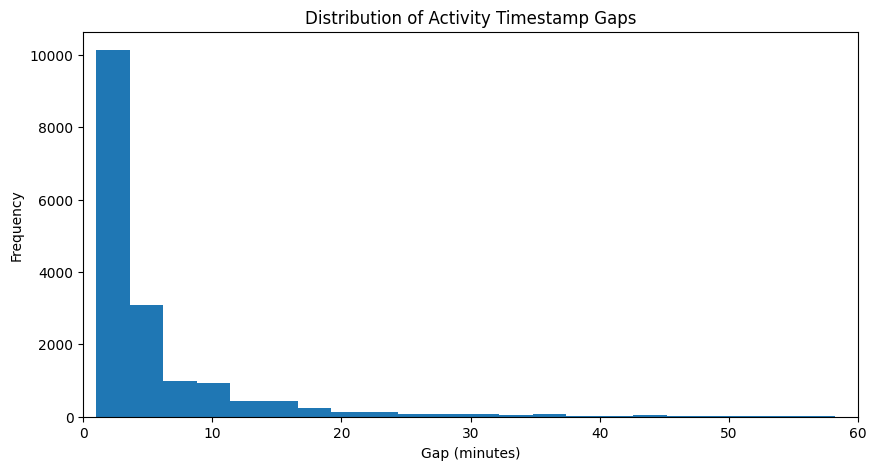

In [ ]:
df_activity = df_monitoring_test_sorted[valid_activity_mask].copy()

df_activity['gap_minutes'] = df_activity.groupby('filename')['timestamp'].diff().dt.total_seconds() / 60

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df_activity['gap_minutes'].dropna(), bins=100)

plt.xlabel('Gap (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Activity Timestamp Gaps')

plt.xlim(0, 60)  # focus on useful range
plt.show()

It looks like 15 minutes would be a sensible amount of time to allow propagation of activity labels, but I also want to use heart rate and the activity type of generic to indicate whether or not I should continue to propagate an activity type: 'generic' indicates that something is happening, but Garmin doesn't know what it is, so it's weak evidence that an activity label should continue to propagate and thus I want 'generic' to refresh the 15-minute timer; if heart rate varies significantly from the value associated with the orignial explicitly listed activity type, then propagation should probably stop. To determine what ranges of heart rate I want to have support the different activity types, I'll create plots of the heart rate listed at times with explicit activity labels and determine reasonable values from there.

<Axes: xlabel='activity_type', ylabel='heart_rate'>

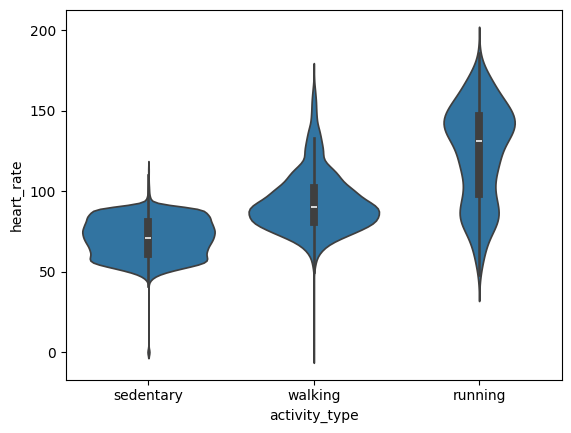

In [ ]:
import seaborn as sns

sns.violinplot(
    data = df_monitoring_test_sorted.loc[
        df_monitoring_test_sorted['activity_type'].isin([
            'running',
            'walking',
            'sedentary'
        ])
    ],
    x = 'activity_type',
    y = 'heart_rate'
)

Based on this, I will say that sedentary activity labels should propagate if they are below the 97th percentile, walking labels if they are between the 5th and 97th percentiles, and running labels if they are above the 3rd percentile. When I eventually add data that includes cycling activity labels, I will try implementing a bound from the 3rd to 97th percentiles as a rough rule of thumb.

In [ ]:
monitoring_b_folder_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)/monitoring_b'

# create list of filenames
files = sorted(os.listdir(monitoring_b_folder_test_256))

# create lists of messages and fields to include as df columns
wanted_msgs = ['monitoring']

wanted_fields = ['timestamp', 'distance', 'cycles', 'steps', 'activity_type', 'timestamp_16', 'heart_rate']

# initialize empty sets of rows that data will get added to
rows_monitoring = []

# parse all of the files in the test monitoring_b folder
for filename in files:
  full_monitoring_path_test_256 = os.path.join(monitoring_b_folder_test_256, filename)

  # iterate through all messages and fields
  with fitdecode.FitReader(full_monitoring_path_test_256) as fit:
    for frame in fit:
      if isinstance(frame, fitdecode.FitDataMessage):
        msg_name = frame.name

        if msg_name == 'monitoring':              # include monitoring message category only
          row = {}                                # create space for all data corresponding to a single timestamp

          if any(field.name in wanted_fields for field in frame.fields):        # process only frames with useful fields
            for field in frame.fields:
              field_name = field.name

              if field_name in wanted_fields:
                row[field_name] = field.value

            if row:                                 # only append if row has data
              row['filename'] = filename            # include filename to allow traceback and sorting

              rows_monitoring.append(row)


# make dfs
df_monitoring_test = pd.DataFrame(rows_monitoring)


# show more of the df
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# sort df chronologically

df_monitoring_test_list = []

# group to sort within files
for filename, group in df_monitoring_test.groupby('filename'):
  group.reset_index(drop = True, inplace = True)

  # reconstruct timestamps from timestamp_16 (16-bit rolling timestamps)

  # initialize list of reconstructed timestamps and most recent time data
  reconstructed_timestamps = []
  last_ts = None
  last_ts_16 = None

  # forward fill (reconstruct) time stamps
  for idx, row in group.iterrows():
    ts = row['timestamp']
    ts_16 = row['timestamp_16']

    # add explicit timestamps to the list of reconstructed timestamps and update the most recent values
    if pd.notna(ts):
      last_ts = ts
      reconstructed_timestamps.append(ts)

    # add implicit timestamps following an explicit timestamp
    elif pd.notna(ts_16) and last_ts is not None:
      # initialize last_ts_16
      if last_ts_16 is None:
        last_ts_16 = ts_16
        reconstructed_timestamps.append(last_ts)

      else:
        delta = ts_16 - last_ts_16

        # deal with delta exceeding 16-bit integer limit
        if delta < -32768:
          delta += 65536
        if delta > 32768:
          delta -= 65536

        new_ts = last_ts + pd.Timedelta(seconds = delta)

        last_ts = new_ts
        last_ts_16 = ts_16
        reconstructed_timestamps.append(new_ts)

    # prevent misalignment of rows due to missing time data
    else:
      reconstructed_timestamps.append(pd.NaT)

  group['timestamp'] = reconstructed_timestamps

  # back fill (reconstruct) timestamps
  for i in range(len(group) - 2, -1, -1):
    if pd.isna(group.loc[i, 'timestamp']):
      next_ts = group.loc[i + 1, 'timestamp']
      current_ts_16 = group.loc[i, 'timestamp_16']
      next_ts_16 = group.loc[i + 1, 'timestamp_16']

      if pd.notna(next_ts) and pd.notna(current_ts_16) and pd.notna(next_ts_16):
        delta = current_ts_16 - next_ts_16

        # deal with delta exceeding 16-bit integer limit
        if delta < -32768:
          delta += 65536
        if delta > 32768:
          delta -= 65536

        group.loc[i, 'timestamp'] = next_ts + pd.Timedelta(seconds = delta)

  # add sorted groups to main df
  df_monitoring_test_list.append(group)

# convert from list to df
df_monitoring_test_sorted = pd.concat(df_monitoring_test_list)

# drop rows with no important data
df_monitoring_test_sorted['activity_type'] = df_monitoring_test_sorted['activity_type'].replace('None', pd.NA)
df_monitoring_test_sorted.dropna(how = 'all', subset = ['activity_type', 'heart_rate', 'distance', 'steps'], inplace = True)

# classify activity labels
explicit_labels = {'sedentary', 'walking', 'cycling', 'running'}
generic_labels = {'generic', 'active', 'unknown'}

# condense data per timestamp

# sort by time within file
df_monitoring_test_sorted = df_monitoring_test_sorted.sort_values(['filename', 'timestamp'])

# define function to prioritize meaningful activity labels
def resolve_activity(labels):
  labels = labels.dropna().astype(str)

  explicit = labels[labels.isin(explicit_labels)]
  if len(explicit) > 0:
    return explicit.iloc[-1]

  generic = labels[labels.isin(generic_labels)]
  if len(generic) > 0:
    return generic.iloc[-1]

  return pd.NA

# aggregate data per timestamp
df_monitoring_test_sorted = (df_monitoring_test_sorted.groupby(['filename', 'timestamp'], as_index = False).agg({'activity_type': resolve_activity,
                                                                                                                 'heart_rate': 'mean',
                                                                                                                 'steps': 'max',
                                                                                                                 'distance': 'max'}))
df_monitoring_test_sorted = df_monitoring_test_sorted.sort_values('timestamp')

# convert unrealistic heart rates to NaN
df_monitoring_test_sorted.loc[df_monitoring_test_sorted['heart_rate'] <= 30,'heart_rate'] = pd.NA

# propagate activity labels

# empty column of cleaned activity labels
df_monitoring_test_sorted['activity_cleaned'] = pd.NA

# define reasonable heart rate bounds and a function to check if hr is in them
bounds = {
    'sedentary': {'upper': df_monitoring_test_sorted.loc[df_monitoring_test_sorted['activity_type'] == 'sedentary', 'heart_rate'].dropna().quantile(0.97)},
    'walking': {'lower': df_monitoring_test_sorted.loc[df_monitoring_test_sorted['activity_type'] == 'walking', 'heart_rate'].dropna().quantile(0.05),
                'upper': df_monitoring_test_sorted.loc[df_monitoring_test_sorted['activity_type'] == 'walking', 'heart_rate'].dropna().quantile(0.97)},
    'cycling': {'lower': df_monitoring_test_sorted.loc[df_monitoring_test_sorted['activity_type'] == 'cycling', 'heart_rate'].dropna().quantile(0.03),
                'upper': df_monitoring_test_sorted.loc[df_monitoring_test_sorted['activity_type'] == 'cycling', 'heart_rate'].dropna().quantile(0.97)},
    'running': {'lower': df_monitoring_test_sorted.loc[df_monitoring_test_sorted['activity_type'] == 'running', 'heart_rate'].dropna().quantile(0.03)}
}

def hr_reasonable(activity, hr):
  if pd.isna(hr):
    return True       # prevents invalid heart rates from stopping propagation
  elif activity == 'sedentary':
    return hr <= bounds['sedentary']['upper']
  elif activity == 'walking':
    return bounds['walking']['lower'] <= hr <= bounds['walking']['upper']
  elif activity == 'cycling':
    return bounds['cycling']['lower'] <= hr <= bounds['cycling']['upper']
  elif activity == 'running':
    return bounds['running']['lower'] <= hr
  else:
    return False

# initialize variables
expiry = None    # time-based countdown
last_state = None     # tracks last explicit activity label

for row in df_monitoring_test_sorted.itertuples():
  label = row.activity_type
  hr = row.heart_rate
  t = row.timestamp
  idx = row.Index

  # handle explicit labels
  if label in explicit_labels:
    last_state = label
    expiry = t + pd.Timedelta(minutes = 15)
    df_monitoring_test_sorted.at[idx, 'activity_cleaned'] = label

  else:
    # handle generic labels
    if label in generic_labels and expiry is not None:
      expiry = min(expiry + pd.Timedelta(minutes = 3), t + pd.Timedelta(minutes = 15))

    # propagation
    if last_state is not None and expiry is not None and t <= expiry and hr_reasonable(last_state, hr):
      df_monitoring_test_sorted.at[idx, 'activity_cleaned'] = last_state

    # preserve explicit generic labels if propagation failed
    elif pd.isna(df_monitoring_test_sorted.at[idx, 'activity_cleaned']):
      if label in generic_labels:
        df_monitoring_test_sorted.at[idx, 'activity_cleaned'] = 'generic'

# convert time zone from UTC to local time, accounting for daylight savings automatically
df_monitoring_test_sorted['timestamp'] = df_monitoring_test_sorted['timestamp'].dt.tz_convert('America/Los_Angeles')

df_monitoring_test_sorted.head(100)

,filename,timestamp,activity_type,heart_rate,steps,distance,activity_cleaned
10,legomyeyeball@gmail.com_105039634639.fit,2016-12-31 15:59:00-08:00,<NA>,NaN,NaN,NaN,<NA>
11,legomyeyeball@gmail.com_105039634639.fit,2016-12-31 16:00:00-08:00,sedentary,NaN,NaN,NaN,sedentary
0,legomyeyeball@gmail.com_105039632873.fit,2021-01-17 14:16:00-08:00,sedentary,NaN,NaN,NaN,sedentary
1,legomyeyeball@gmail.com_105039632873.fit,2021-01-17 14:17:00-08:00,sedentary,NaN,NaN,NaN,sedentary
2,legomyeyeball@gmail.com_105039632873.fit,2021-01-17 14:19:00-08:00,sedentary,NaN,NaN,NaN,sedentary
3,legomyeyeball@gmail.com_105039632873.fit,2021-01-17 14:20:00-08:00,sedentary,NaN,NaN,NaN,sedentary
4,legomyeyeball@gmail.com_105039632873.fit,2021-01-17 14:21:00-08:00,sedentary,NaN,NaN,NaN,sedentary
5,legomyeyeball@gmail.com_105039632873.fit,2021-01-17 14:23:00-08:00,sedentary,NaN,NaN,NaN,sedentary
6,legomyeyeball@gmail.com_105039632873.fit,2021-01-17 14:27:00-08:00,sedentary,NaN,NaN,NaN,sedentary
7,legomyeyeball@gmail.com_105039632873.fit,2021-01-17 14:28:00-08:00,sedentary,NaN,NaN,NaN,sedentary


This seems like it's in a good position now. I had to go back and forth a few times to tweak various aspects of how labels were propagated, including guaranteeing that if there is an explicit 'generic' label but any potentially existing explicit label of actual meaning (for example, 'walking') cannot propagate (for example, due to heart rate being unreasonable), then the 'generic' label will still be kept rather than discarded in favor <NA>. While I'm aware it's probably not the best practice, I don't want to deal with seeing the original activity column or having yet another dataframe, so I'm going to drop the old activity column and keep the cleaned one instead.

Additionally, I still need to improve my resolution of duplicate timestamps. I think this stems from grouping within files rather than across files, so I'm going to change that and ensure that I'm aggregating properly for each type of data I have. Notably, for heart rate, in cases where I have multiple non-null values, I will be taking the value closest to the preceding value (within a short time frame) rather than an average in an effort to reduce artifacts and misreads, as I think I remember noticing this at times.

In [ ]:
import numpy as np

monitoring_b_folder_test_256 = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)/monitoring_b'

# create list of filenames
files = sorted(os.listdir(monitoring_b_folder_test_256))

# create lists of messages and fields to include as df columns
wanted_msgs = ['monitoring']

wanted_fields = ['timestamp', 'distance', 'cycles', 'steps', 'activity_type', 'timestamp_16', 'heart_rate']

# initialize empty sets of rows that data will get added to
rows_monitoring = []

# parse all of the files in the test monitoring_b folder
for filename in files:
  full_monitoring_path_test_256 = os.path.join(monitoring_b_folder_test_256, filename)

  # iterate through all messages and fields
  with fitdecode.FitReader(full_monitoring_path_test_256) as fit:
    for frame in fit:
      if isinstance(frame, fitdecode.FitDataMessage):
        msg_name = frame.name

        if msg_name == 'monitoring':              # include monitoring message category only
          row = {}                                # create space for all data corresponding to a single timestamp

          if any(field.name in wanted_fields for field in frame.fields):        # process only frames with useful fields
            for field in frame.fields:
              field_name = field.name

              if field_name in wanted_fields:
                row[field_name] = field.value

            if row:                                 # only append if row has data
              row['filename'] = filename            # include filename to allow traceback and sorting

              rows_monitoring.append(row)


# make dfs
df_monitoring_test = pd.DataFrame(rows_monitoring)


# show more of the df
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# sort df chronologically

df_monitoring_test_list = []

# group to sort within files
for filename, group in df_monitoring_test.groupby('filename'):
  group.reset_index(drop = True, inplace = True)

  # reconstruct timestamps from timestamp_16 (16-bit rolling timestamps)

  # initialize list of reconstructed timestamps and most recent time data
  reconstructed_timestamps = []
  last_ts = None
  last_ts_16 = None

  # forward fill (reconstruct) time stamps
  for idx, row in group.iterrows():
    ts = row['timestamp']
    ts_16 = row['timestamp_16']

    # add explicit timestamps to the list of reconstructed timestamps and update the most recent values
    if pd.notna(ts):
      last_ts = ts
      reconstructed_timestamps.append(ts)

    # add implicit timestamps following an explicit timestamp
    elif pd.notna(ts_16) and last_ts is not None:
      # initialize last_ts_16
      if last_ts_16 is None:
        last_ts_16 = ts_16
        reconstructed_timestamps.append(last_ts)

      else:
        delta = ts_16 - last_ts_16

        # deal with delta exceeding 16-bit integer limit
        if delta < -32768:
          delta += 65536
        if delta > 32768:
          delta -= 65536

        new_ts = last_ts + pd.Timedelta(seconds = delta)

        last_ts = new_ts
        last_ts_16 = ts_16
        reconstructed_timestamps.append(new_ts)

    # prevent misalignment of rows due to missing time data
    else:
      reconstructed_timestamps.append(pd.NaT)

  group['timestamp'] = reconstructed_timestamps

  # back fill (reconstruct) timestamps
  for i in range(len(group) - 2, -1, -1):
    if pd.isna(group.loc[i, 'timestamp']):
      next_ts = group.loc[i + 1, 'timestamp']
      current_ts_16 = group.loc[i, 'timestamp_16']
      next_ts_16 = group.loc[i + 1, 'timestamp_16']

      if pd.notna(next_ts) and pd.notna(current_ts_16) and pd.notna(next_ts_16):
        delta = current_ts_16 - next_ts_16

        # deal with delta exceeding 16-bit integer limit
        if delta < -32768:
          delta += 65536
        if delta > 32768:
          delta -= 65536

        group.loc[i, 'timestamp'] = next_ts + pd.Timedelta(seconds = delta)

  # add sorted groups to main df
  df_monitoring_test_list.append(group)

# convert from list to df
df_monitoring_test_sorted = pd.concat(df_monitoring_test_list)

# drop rows with no important data
df_monitoring_test_sorted['activity_type'] = df_monitoring_test_sorted['activity_type'].replace('None', pd.NA)
df_monitoring_test_sorted.dropna(how = 'all', subset = ['activity_type', 'heart_rate', 'distance', 'steps'], inplace = True)

# classify activity labels
explicit_labels = {'sedentary', 'walking', 'cycling', 'running'}
generic_labels = {'generic', 'active', 'unknown'}


# condense data per timestamp

# sort globally by time
df_monitoring_test_sorted = df_monitoring_test_sorted.sort_values(['timestamp', 'filename']).reset_index(drop=True)

# define function to preserve explicit labels over generic labels
def resolve_activity(labels):
  labels = labels.dropna().astype(str)

  explicit = labels[labels.isin(explicit_labels)]
  if not explicit.empty:
    return explicit.iloc[-1]

  elif not labels.empty:
    return labels.iloc[-1]

  return pd.NA

# define function to preserve filenames of duplicated rows for traceability
def combine_filenames(series):
  return '; '.join(sorted(series.dropna().unique()))

# drop unrealistic heart rate values
df_monitoring_test_sorted.loc[df_monitoring_test_sorted['heart_rate'] <= 30,'heart_rate'] = pd.NA

# aggregate non-heart rate fields globally per timestamp
df_monitoring_test_aggregated = (
  df_monitoring_test_sorted
  .groupby('timestamp', as_index=False)
  .agg({
    'filename': combine_filenames,
    'activity_type': resolve_activity,
    'steps': 'max',
    'distance': 'max'
  })
)

# resolve heart rate

# initialize variables
hr_groups = list(df_monitoring_test_sorted.groupby('timestamp', sort=True))

resolved_hrs = []

last_valid_hr = None
last_valid_time = None

max_gap = pd.Timedelta(minutes=3)       # only compare to heart rates 3 minutes ago or less

# iterate through duplicate timestamps and pick the one closest to valid prior heart rates
for timestamp, group in hr_groups:

  hr_candidates = group['heart_rate'].dropna().unique()
  resolved_hr = np.nan

  if len(hr_candidates) == 1:
    resolved_hr = hr_candidates[0]

  elif len(hr_candidates) > 1:
    if last_valid_hr is not None and last_valid_time is not None and (timestamp - last_valid_time) <= max_gap:
      resolved_hr = min(hr_candidates,key=lambda hr: abs(hr - last_valid_hr))

    else:
      resolved_hr = np.median(hr_candidates)

  if pd.notna(resolved_hr):
    last_valid_hr = resolved_hr
    last_valid_time = timestamp

  resolved_hrs.append({'timestamp': timestamp,'heart_rate': resolved_hr})

df_monitoring_test_cleaned_hr = pd.DataFrame(resolved_hrs)

# merge condensed dataframes
df_monitoring_test_sorted = df_monitoring_test_aggregated.merge(df_monitoring_test_cleaned_hr, on='timestamp', how='left').sort_values('timestamp').reset_index(drop=True)


# propagate activity labels

# empty column of cleaned activity labels
df_monitoring_test_sorted['activity_cleaned'] = pd.NA

# define reasonable heart rate bounds and a function to check if hr is in them
bounds = {
    'sedentary': {'upper': df_monitoring_test_sorted.loc[df_monitoring_test_sorted['activity_type'] == 'sedentary', 'heart_rate'].dropna().quantile(0.97)},
    'walking': {'lower': df_monitoring_test_sorted.loc[df_monitoring_test_sorted['activity_type'] == 'walking', 'heart_rate'].dropna().quantile(0.05),
                'upper': df_monitoring_test_sorted.loc[df_monitoring_test_sorted['activity_type'] == 'walking', 'heart_rate'].dropna().quantile(0.97)},
    'cycling': {'lower': df_monitoring_test_sorted.loc[df_monitoring_test_sorted['activity_type'] == 'cycling', 'heart_rate'].dropna().quantile(0.03),
                'upper': df_monitoring_test_sorted.loc[df_monitoring_test_sorted['activity_type'] == 'cycling', 'heart_rate'].dropna().quantile(0.97)},
    'running': {'lower': df_monitoring_test_sorted.loc[df_monitoring_test_sorted['activity_type'] == 'running', 'heart_rate'].dropna().quantile(0.03)}
}

def hr_reasonable(activity, hr):
  if pd.isna(hr):
    return True       # prevents invalid heart rates from stopping propagation
  elif activity == 'sedentary':
    return hr <= bounds['sedentary']['upper']
  elif activity == 'walking':
    return bounds['walking']['lower'] <= hr <= bounds['walking']['upper']
  elif activity == 'cycling':
    return bounds['cycling']['lower'] <= hr <= bounds['cycling']['upper']
  elif activity == 'running':
    return bounds['running']['lower'] <= hr
  else:
    return False

# initialize variables
expiry = None    # time-based countdown
last_state = None     # tracks last explicit activity label

for row in df_monitoring_test_sorted.itertuples():
  label = row.activity_type
  hr = row.heart_rate
  t = row.timestamp
  idx = row.Index

  # handle explicit labels
  if label in explicit_labels:
    last_state = label
    expiry = t + pd.Timedelta(minutes = 15)
    df_monitoring_test_sorted.at[idx, 'activity_cleaned'] = label

  else:
    # handle generic labels
    if label in generic_labels and expiry is not None:
      expiry = min(expiry + pd.Timedelta(minutes = 3), t + pd.Timedelta(minutes = 15))

    # propagation
    if last_state is not None and expiry is not None and t <= expiry and hr_reasonable(last_state, hr):
      df_monitoring_test_sorted.at[idx, 'activity_cleaned'] = last_state

    # preserve explicit generic labels if propagation failed
    elif pd.isna(df_monitoring_test_sorted.at[idx, 'activity_cleaned']):
      if label in generic_labels:
        df_monitoring_test_sorted.at[idx, 'activity_cleaned'] = 'generic'

# drop old activity column and reorder
df_monitoring_test_sorted.drop(columns = ['activity_type'], inplace = True)
df_monitoring_test_sorted = df_monitoring_test_sorted[['filename', 'timestamp', 'activity_cleaned', 'heart_rate', 'steps', 'distance']]

# convert time zone from UTC to local time, accounting for daylight savings automatically
df_monitoring_test_sorted['timestamp'] = df_monitoring_test_sorted['timestamp'].dt.tz_convert('America/Los_Angeles')

df_monitoring_test_sorted

,filename,timestamp,activity_cleaned,heart_rate,steps,distance
0,legomyeyeball@gmail.com_105039634639.fit,2016-12-31 15:59:00-08:00,<NA>,NaN,NaN,NaN
1,legomyeyeball@gmail.com_105039634639.fit,2016-12-31 16:00:00-08:00,sedentary,NaN,NaN,NaN
2,legomyeyeball@gmail.com_105039632873.fit,2021-01-17 14:16:00-08:00,sedentary,NaN,NaN,NaN
3,legomyeyeball@gmail.com_105039632873.fit,2021-01-17 14:17:00-08:00,sedentary,NaN,NaN,NaN
4,legomyeyeball@gmail.com_105039632873.fit,2021-01-17 14:19:00-08:00,sedentary,NaN,NaN,NaN
...,...,...,...,...,...,...
76250,legomyeyeball@gmail.com_114817738127.fit,2021-11-27 19:21:00-08:00,sedentary,NaN,NaN,NaN
76251,legomyeyeball@gmail.com_114817738127.fit,2021-11-27 19:22:00-08:00,sedentary,NaN,NaN,NaN
76252,legomyeyeball@gmail.com_114817738127.fit,2021-11-27 19:23:00-08:00,sedentary,61.0,NaN,NaN
76253,legomyeyeball@gmail.com_114817738127.fit,2021-11-27 19:24:00-08:00,running,62.0,5924.0,7128.54


In [ ]:
df_monitoring_test_sorted['timestamp'].nunique()

76255

With this, I think the duplicates are finally handled, which means I can finally move on from preprocessing the monitoring files. Sort of. I want to make sure all of the steps in my pipeline are efficient, can handle and inform me of exceptions, and are cleaned up to be a bit more readable before I put in the larger set of all 15000+ files. Also, I want to use the same parser throughout, so I'll switch the earlier blocks to the second parser. Another big thing I'll be doing is copying the files to a local disk instead of Drive, given how slow Drive is with accessing many (for instance, 15000+) small files, and I'll also be utilizing multiprocessing techniques to speed things up more (I REALLY don't want this to take forever every single time I run anything on the whole set of files, hence all of these optimizations). I'll begin implementing these changes with the folder-sorting system.

In [ ]:
import os
import shutil
import time
import logging
!pip install fitdecode
import fitdecode
!pip install pyarrow
import pyarrow
import pandas as pd
import numpy as np

from concurrent.futures import ProcessPoolExecutor, as_completed
from multiprocessing import cpu_count


# google Drive source folder (slow storage)
drive_folder = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/256 test files (duplicates)'

# local Colab storage (fast temporary storage)
local_folder = '/content/fit_working_data'

# explicit folder structure within local storage (created later)
activity_folder = os.path.join(local_folder, 'activity')
monitoring_b_folder = os.path.join(local_folder, 'monitoring_b')


# configure logging:
# any parsing errors will be saved to this file instead of cluttering notebook output
logging.basicConfig(filename='fit_processing_errors.log', level=logging.ERROR,format='%(asctime)s - %(message)s')


# remove old local copy if it exists to prevent duplicate files from previous runs
if os.path.exists(local_folder):
  shutil.rmtree(local_folder)


print('Copying files from Drive to local Colab storage...')

copy_start = time.time()

# copy entire dataset from Drive to local runtime storage
shutil.copytree(drive_folder, local_folder)

copy_elapsed = time.time() - copy_start

print(f'Copy complete in {copy_elapsed:.2f} seconds.\n')


def get_file_type(filepath):
  try:

    # open fit file
    with fitdecode.FitReader(filepath) as fit:

      # iterate through all frames/messages in fit file
      for frame in fit:

        # single out data messages named 'file_id'
        if isinstance(frame, fitdecode.FitDataMessage) and frame.name == 'file_id':

          # search fields inside the "file_id" message
          for field in frame.fields:

            # extract the "type" field value
            if field.name == 'type':
              return field.value

  # handle corrupted/unreadable files safely
  except Exception as e:
    logging.error(f'Error processing {os.path.basename(filepath)}: {e}')

  # fallback if no type is found
  return 'unknown'


def process_file(filename):

  # build full local file path
  src_path = os.path.join(local_folder, filename)

  # parse file type from fit file
  file_type = get_file_type(src_path)

  # return both values because multiprocessing workers can't directly modify main-process variables
  return filename, file_type


# build list of only .fit files
files = []

for file in os.listdir(local_folder):
  if file.endswith('.fit'):
    files.append(file)

total_files = len(files)
print(f'Found {total_files} .fit files.\n')


start_time = time.time()

# use all CPU cores except one (leaving one free keeps system responsive)
num_workers = max(cpu_count() - 1, 1)

print(f'Using {num_workers} CPU workers.\n')

# track folders that are already created to revent repeated filesystem calls
created_dirs = set()


# create multiprocessing pool
with ProcessPoolExecutor(max_workers=num_workers) as executor:

  # submit all file-processing jobs immediately
  # executor.submit(...) schedules a task on a worker process
  # each call returns a 'future' object--a placeholder representing work that may still be running
  futures = {}

  for filename in files:

      # submit task to worker process
      future = executor.submit(process_file, filename)

      # store mapping (future object -> filename)
      futures[future] = filename

  # counter for completed files
  completed = 0

  # as_completed() yields future objects in the order they finish, not submission order
  for future in as_completed(futures):
    completed += 1

    # retrieve returned values from worker process
    # .result() waits if task isn't finished yet and raises exceptions if worker crashed
    filename, file_type = future.result()
    src_path = os.path.join(local_folder, filename)
    dest_folder = os.path.join(local_folder, file_type)

    # create destination folder only once
    if file_type not in created_dirs:
      os.makedirs(dest_folder, exist_ok=True)
      created_dirs.add(file_type)

    # move file into type-specific folder
    shutil.move(src_path, os.path.join(dest_folder, filename))

    # print progress every 100 files because why not
    if completed % 100 == 0 or completed == total_files:
      elapsed = time.time() - start_time
      avg_time = elapsed / completed
      remaining = total_files - completed

      # ETA estimate:
      eta_seconds = avg_time * remaining

      print(
        f'{completed}/{total_files} '
        f'({completed/total_files:.1%}) | '
        f'ETA: {eta_seconds/60:.2f} min'
      )


# output folder back on Drive
output_drive_folder = drive_folder + '_SORTED'


# remove old output folder if it exists
if os.path.exists(output_drive_folder):
    shutil.rmtree(output_drive_folder)


print('\nCopying sorted files back to Google Drive...')

# track how long copying back takes because why not
copy_back_start = time.time()

# copy sorted results from local storage -> Drive
shutil.copytree(local_folder, output_drive_folder)

copy_back_elapsed = time.time() - copy_back_start

print(f'Finished copying back in {copy_back_elapsed:.2f} seconds.')


total_elapsed = time.time() - start_time

print('\nDone.')
print(f'Total processing time: {total_elapsed/60:.2f} minutes')

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

KeyboardInterrupt: 

This seems to work well for the test subset, and as an added benefit, it looks super fancy too! I'm going to move on to processing the activity files. Some big (and small) improvements I can make here include combining much of the work on the activity and session files so I don't parse everything multiple times, then building dfs and doing timestamp stuff, and also turning some lists into sets. I will not utilize multiprocessing here, as the whole "futures"/"as_completed" thing will return stuff out of order and make time gains a whole lot more marginal after I deal with that at the cost of a lot of readability and complexity. Also, at this point, I will be assuming that I will be running blocks of code sequentially rather than as standalone blocks, so I'm going to skip some of the setup I already put in the previous block.

In [ ]:
# define wanted fields
record_fields = {'timestamp', 'position_lat', 'position_long', 'distance', 'enhanced_speed', 'heart_rate', 'cadence'}
session_fields = {'start_time', 'timestamp', 'total_distance', 'total_strides', 'enhanced_avg_speed', 'sport', 'avg_heart_rate', 'max_heart_rate', 'avg_running_cadence', 'max_running_cadence'}

# initialize storage structures
rows_record = []
rows_session = []
file_times = []   # (filename, start_time)


# create file list
files = []

for file in os.listdir(activity_folder):
  if file.endswith('.fit'):
    files.append(file)
files.sort()              # sorted only for repeatability across runs
total_files = len(files)


# parse the files
start_time = time.time()

for i, filename in enumerate(files, start = 1):
  full_path = os.path.join(activity_folder, filename)
  start_time_value = pd.NaT

  try:
    with fitdecode.FitReader(full_path) as fit:
      for frame in fit:
        if not isinstance(frame, fitdecode.FitDataMessage):
          continue

        msg = frame.name

        # convert fields to dicts for fast lookup
        fields = {
          field.name: field.value
          for field in frame.fields
          if field.name is not None
        }

        # session data
        if msg == "session":
          if pd.isna(start_time_value):
            start_time_value = fields.get("start_time", pd.NaT)

          row = {}
          for key, value in fields.items():
            if key in session_fields:
              row[key] = value

          if row:
            row["filename"] = filename
            rows_session.append(row)

        # record data
        elif msg == "record":

          row = {}
          for key, value in fields.items():
            if key in record_fields:
              row[key] = value

          if row:
            row["filename"] = filename
            rows_record.append(row)

    # store file-level timing info
    file_times.append((filename, start_time_value))

  except Exception as e:
    logging.error(f'Error processing {filename}: {e}')


  # progress every 100 files and ETA
  if i % 100 == 0 or i == total_files:
    elapsed = time.time() - start_time
    avg = elapsed / i
    eta = avg * (total_files - i)

    print(
      f"{i}/{total_files} "
      f"({i/total_files:.1%}) | "
      f"ETA: {eta/60:.2f} min"
    )


# add chronological activity ids

file_times_sorted = sorted(
    file_times,
    key=lambda x: x[1] if x[1] is not None else pd.Timestamp.max
)

file_to_id = {}

for i, (filename, start_time) in enumerate(file_times_sorted):
  file_to_id[filename] = i


for r in rows_record:
    r['activity_id'] = file_to_id.get(r['filename'], -1)

for r in rows_session:
    r['activity_id'] = file_to_id.get(r['filename'], -1)


# create dataframes
df_record = pd.DataFrame(rows_record)
df_session = pd.DataFrame(rows_session)


# convert timezones
for df in (df_record, df_session):
  if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc = True).dt.tz_convert('America/Los_Angeles')


# sort dataframes
for df in (df_record, df_session):
  if not df.empty:
    df.sort_values(by=['activity_id', 'timestamp'], inplace = True)


print("\nDone.")
print(f"Records: {len(df_record)} | Sessions: {len(df_session)}")

65/65 (100.0%) | ETA: 0.00 min

Done.
Records: 89219 | Sessions: 65


In [ ]:
# show dfs for testing purposes
df_record.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89219 entries, 0 to 89218
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype                              
---  ------          --------------  -----                              
 0   timestamp       89219 non-null  datetime64[ns, America/Los_Angeles]
 1   position_lat    72775 non-null  float64                            
 2   position_long   72775 non-null  float64                            
 3   distance        89219 non-null  float64                            
 4   enhanced_speed  89219 non-null  float64                            
 5   heart_rate      89195 non-null  float64                            
 6   cadence         89219 non-null  int64                              
 7   filename        89219 non-null  object                             
 8   activity_id     89219 non-null  int64                              
dtypes: datetime64[ns, America/Los_Angeles](1), float64(5), int64(2), object(1)
memory usage: 

In [ ]:
df_session.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65 entries, 0 to 64
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype                              
---  ------               --------------  -----                              
 0   start_time           65 non-null     datetime64[ns, UTC]                
 1   total_distance       65 non-null     float64                            
 2   enhanced_avg_speed   65 non-null     float64                            
 3   timestamp            65 non-null     datetime64[ns, America/Los_Angeles]
 4   sport                65 non-null     object                             
 5   filename             65 non-null     object                             
 6   activity_id          65 non-null     int64                              
 7   total_strides        64 non-null     float64                            
 8   avg_heart_rate       64 non-null     float64                            
 9   max_heart_rate       64 non-null     fl

Awesome, this seems to work too! Next up is the monitoring files. I'll keep these separate from the other ones since they're different files, not different fields, but I think I'll make many of the same sorts of improvements.

In [ ]:
# define wanted fields and label categories
wanted_fields = {'timestamp', 'distance', 'cycles', 'steps', 'activity_type', 'timestamp_16', 'heart_rate'}
explicit_labels = {'sedentary', 'walking', 'cycling', 'running'}
generic_labels = {'generic', 'active', 'unknown'}

# parse monitoring files
print('Parsing monitoring files...')

# sort files
files = []

for file in os.listdir(monitoring_b_folder):
  if file.endswith('.fit'):
    files.append(file)

files = sorted(files)

# create space for parsed files
rows = []

for filename in files:
  filepath = os.path.join(monitoring_b_folder, filename)
  try:

    # parse and iterate through files
    with fitdecode.FitReader(filepath) as fit:
      for frame in fit:
        if isinstance(frame, fitdecode.FitDataMessage):

          # only work with monitoring fields
          if frame.name == 'monitoring':
            row = {}

            for field in frame.fields:
              if field.name in wanted_fields:
                row[field.name] = field.value

            if row:
              row['filename'] = filename
              rows.append(row)

  except Exception as e:
    logging.error(f'Error parsing {filename}: {e}')

# build dataframe
print('Building dataframe...')
df_monitoring = pd.DataFrame(rows)

# recast select dtypes for memory optimization
df_monitoring['filename'] = df_monitoring['filename'].astype('category')
df_monitoring['heart_rate'] = df_monitoring['heart_rate'].astype('float32')
df_monitoring['steps'] = df_monitoring['steps'].astype('float32')
df_monitoring['distance'] = df_monitoring['distance'].astype('float32')

# timestamp reconstruction
def reconstruct_timestamps(group):
  group = group.reset_index(drop=True).copy()
  reconstructed_timestamps = []

  last_ts = None
  last_ts_16 = None

  # forward reconstruction
  for row in group.itertuples():
    ts = row.timestamp
    ts_16 = row.timestamp_16

    if pd.notna(ts):
      last_ts = ts
      reconstructed_timestamps.append(ts)

    elif pd.notna(ts_16) and last_ts is not None:
        if last_ts_16 is None:
          last_ts_16 = ts_16
          reconstructed_timestamps.append(last_ts)

        else:
          delta = ts_16 - last_ts_16

          if delta < -32768:
            delta += 65536
          elif delta > 32768:
            delta -= 65536

          new_ts = last_ts + pd.Timedelta(seconds=delta)
          last_ts = new_ts
          last_ts_16 = ts_16

          reconstructed_timestamps.append(new_ts)

    # append NaT for preservation purposes
    else:
      reconstructed_timestamps.append(pd.NaT)

  group['timestamp'] = reconstructed_timestamps

  # backward reconstruction
  timestamp_values = group['timestamp'].copy()
  timestamp16_values = group['timestamp_16'].copy()

  for i in range(len(group) - 2, -1, -1):
    if pd.isna(timestamp_values.iloc[i]):
      next_ts = timestamp_values.iloc[i + 1]

      if pd.notna(next_ts) and pd.notna(timestamp16_values.iloc[i]) and pd.notna(timestamp16_values.iloc[i + 1]):
        delta = timestamp16_values.iloc[i] - timestamp16_values.iloc[i + 1]

        if delta < -32768:
          delta += 65536
        elif delta > 32768:
          delta -= 65536

        timestamp_values.iloc[i] = next_ts + pd.Timedelta(seconds=delta)

  group['timestamp'] = timestamp_values

  return group

print('Reconstructing timestamps...')
df_monitoring = df_monitoring.groupby('filename', group_keys=False).apply(reconstruct_timestamps).reset_index(drop=True)

# clean missing activity labels
df_monitoring['activity_type'] = df_monitoring['activity_type'].replace('None', pd.NA)

# NaNify unrealistic heart rates
df_monitoring.loc[df_monitoring['heart_rate'] <= 30, 'heart_rate'] = np.nan

# drop empty rows
df_monitoring.dropna(how='all',subset=['activity_type', 'heart_rate', 'distance', 'steps'], inplace=True)

# sort chronologically
df_monitoring = df_monitoring.sort_values(['timestamp', 'filename']).reset_index(drop=True)

# define helper functions

# preserve explicit labels over generic labels
def resolve_activity(labels):
  labels = labels.dropna().astype(str)
  explicit = labels[labels.isin(explicit_labels)]

  if not explicit.empty:
    return explicit.iloc[-1]

  elif not labels.empty:
      return labels.iloc[-1]

  else:
    return pd.NA

# preserve filenames for traceability
def combine_filenames(series):
  return '; '.join(sorted(series.dropna().unique()))

# aggregate duplicate timestamps for non-heart rate data
print('Aggregating duplicate timestamps...')

df_monitoring_aggregated = df_monitoring.groupby('timestamp', as_index=False).agg({'filename': combine_filenames,
                                                                                   'activity_type': resolve_activity,
                                                                                   'steps': 'max',
                                                                                   'distance': 'max'})

# resolve duplicate heart rates
resolved_hrs = []

last_valid_hr = None
last_valid_time = None

max_gap = pd.Timedelta(minutes=3)

for timestamp, group in df_monitoring.groupby('timestamp', sort=True):
  hr_candidates = group['heart_rate'].dropna().unique()
  resolved_hr = np.nan

  # only one heart rate per timestamp
  if len(hr_candidates) == 1:
    resolved_hr = hr_candidates[0]

  # multiple heart rates per timestamp
  elif len(hr_candidates) > 1:

    # preserve heart rate closest to recent valid heart rates
    if last_valid_hr is not None and last_valid_time is not None and (timestamp - last_valid_time) <= max_gap:
      resolved_hr = min(hr_candidates, key=lambda hr: abs(hr - last_valid_hr))

    # no recent valid heart rates
    else:
      resolved_hr = np.median(hr_candidates)

  if pd.notna(resolved_hr):
    last_valid_hr = resolved_hr
    last_valid_time = timestamp

  resolved_hrs.append({'timestamp': timestamp, 'heart_rate': resolved_hr})

df_monitoring_hr = pd.DataFrame(resolved_hrs)

# merge aggregated data and resolved hr data
df_monitoring = df_monitoring_aggregated.merge(df_monitoring_hr, on='timestamp', how='left').sort_values('timestamp').reset_index(drop=True)

# propagate activity labels
print('Propagating activity labels...')

df_monitoring['activity_cleaned'] = pd.NA

# derive realistic heart rate bounds per activity
bounds = {'sedentary': {'upper': df_monitoring.loc[df_monitoring['activity_type'] == 'sedentary', 'heart_rate'].dropna().quantile(0.97)},
          'walking': {'lower': df_monitoring.loc[df_monitoring['activity_type'] == 'walking', 'heart_rate'].dropna().quantile(0.05),
                      'upper': df_monitoring.loc[df_monitoring['activity_type'] == 'walking', 'heart_rate'].dropna().quantile(0.97)},
          'cycling': {'lower': df_monitoring.loc[df_monitoring['activity_type'] == 'cycling', 'heart_rate'].dropna().quantile(0.03),
                      'upper': df_monitoring.loc[df_monitoring['activity_type'] == 'cycling', 'heart_rate'].dropna().quantile(0.97)},
          'running': {'lower': df_monitoring.loc[df_monitoring['activity_type'] == 'running', 'heart_rate'].dropna().quantile(0.03)}}

# validate heart rate plausibility
def hr_reasonable(activity, hr):
  if pd.isna(hr):
    return True

  else:
    if activity == 'sedentary':
      return hr <= bounds['sedentary']['upper']

    elif activity == 'walking':
      return bounds['walking']['lower'] <= hr <= bounds['walking']['upper']

    elif activity == 'cycling':
      return bounds['cycling']['lower'] <= hr <= bounds['cycling']['upper']

    elif activity == 'running':
      return hr >= bounds['running']['lower']

    else:
      return False

# now actually propagate activity labels
expiry = None
last_state = None

for row in df_monitoring.itertuples():
  idx = row.Index
  label = row.activity_type
  hr = row.heart_rate
  t = row.timestamp

  # use explicit labels when present
  if label in explicit_labels:
    last_state = label
    expiry = t + pd.Timedelta(minutes=15)
    df_monitoring.at[idx, 'activity_cleaned'] = label

  else:
    # extend expiry slightly for generic labels
    if label in generic_labels and expiry is not None:
      expiry = min(expiry + pd.Timedelta(minutes=3), t + pd.Timedelta(minutes=15))

    # propagate activity labels where applicable
    if last_state is not None and expiry is not None and t <= expiry and hr_reasonable(last_state, hr):
      df_monitoring.at[idx, 'activity_cleaned'] = last_state

    # preserve generic label if present and propagation fails
    elif label in generic_labels:
      df_monitoring.at[idx,'activity_cleaned'] = 'generic'

# cleanup

# drop old activity column
df_monitoring.drop(columns=['activity_type'], inplace=True)

# reorder columns how I like
df_monitoring = df_monitoring[['filename', 'timestamp', 'activity_cleaned', 'heart_rate', 'steps', 'distance']]

# convert timezone
df_monitoring['timestamp'] = df_monitoring['timestamp'].dt.tz_convert('America/Los_Angeles')

# recast activity dtype for memory purposes
df_monitoring['activity_cleaned'] = df_monitoring['activity_cleaned'].astype('category')

# finish
print('Done.')
df_monitoring

Parsing monitoring files...
Building dataframe...
Reconstructing timestamps...


/tmp/ipykernel_18939/108549060.py:120: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_monitoring = df_monitoring.groupby('filename', group_keys=False).apply(reconstruct_timestamps).reset_index(drop=True)
/tmp/ipykernel_18939/108549060.py:120: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_monitoring = df_monitoring.groupby('filename', group_keys=False).apply(reconstruct_timestamps).reset_index(drop=True)


Aggregating duplicate timestamps...
Propagating activity labels...
Done.


,filename,timestamp,activity_cleaned,heart_rate,steps,distance
0,legomyeyeball@gmail.com_105039634639.fit,2016-12-31 15:59:00-08:00,NaN,NaN,NaN,NaN
1,legomyeyeball@gmail.com_105039634639.fit,2016-12-31 16:00:00-08:00,sedentary,NaN,NaN,NaN
2,legomyeyeball@gmail.com_105039632873.fit,2021-01-17 14:16:00-08:00,sedentary,NaN,NaN,NaN
3,legomyeyeball@gmail.com_105039632873.fit,2021-01-17 14:17:00-08:00,sedentary,NaN,NaN,NaN
4,legomyeyeball@gmail.com_105039632873.fit,2021-01-17 14:19:00-08:00,sedentary,NaN,NaN,NaN
...,...,...,...,...,...,...
75843,legomyeyeball@gmail.com_114817738127.fit,2021-11-27 19:21:00-08:00,sedentary,NaN,NaN,NaN
75844,legomyeyeball@gmail.com_114817738127.fit,2021-11-27 19:22:00-08:00,sedentary,NaN,NaN,NaN
75845,legomyeyeball@gmail.com_114817738127.fit,2021-11-27 19:23:00-08:00,sedentary,61.0,NaN,NaN
75846,legomyeyeball@gmail.com_114817738127.fit,2021-11-27 19:24:00-08:00,running,62.0,5924.0,7128.540039


This seems to work well, and although this is about 400 rows short of what I had previously, I've gone through way too many iterations of this code to care (at one point, my code dropped about 9000 rows, and I had absolutely no clue where or why this happened after two hours of debugging, so I had to just start over), and there's a good chance that this code might just be better at trimming bad stuff/grouping good stuff, so I'll keep this. Given how slow parsing is, I think the biggest timesave I can do would be to save my dataframes externally so that when I start a new runtime I can just upload dataframes that I constructed once rather than reparse it every single time.

In [ ]:
# activity data
def build_activity_data():
  # define wanted fields
  record_fields = {'timestamp', 'position_lat', 'position_long', 'distance', 'enhanced_speed', 'heart_rate', 'cadence'}
  session_fields = {'start_time', 'timestamp', 'total_distance', 'total_strides', 'enhanced_avg_speed', 'sport', 'avg_heart_rate', 'max_heart_rate', 'avg_running_cadence', 'max_running_cadence'}

  # initialize storage structures
  rows_record = []
  rows_session = []
  file_times = []   # (filename, start_time)


  # create file list
  files = []

  for file in os.listdir(activity_folder):
    if file.endswith('.fit'):
      files.append(file)
  files.sort()              # sorted only for repeatability across runs
  total_files = len(files)


  # parse the files
  start_time = time.time()

  for i, filename in enumerate(files, start = 1):
    full_path = os.path.join(activity_folder, filename)
    start_time_value = pd.NaT

    try:
      with fitdecode.FitReader(full_path) as fit:
        for frame in fit:
          if not isinstance(frame, fitdecode.FitDataMessage):
            continue

          msg = frame.name

          # convert fields to dicts for fast lookup
          fields = {
            field.name: field.value
            for field in frame.fields
            if field.name is not None
          }

          # session data
          if msg == "session":
            if pd.isna(start_time_value):
              start_time_value = fields.get("start_time", pd.NaT)

            row = {}
            for key, value in fields.items():
              if key in session_fields:
                row[key] = value

            if row:
              row["filename"] = filename
              rows_session.append(row)

          # record data
          elif msg == "record":

            row = {}
            for key, value in fields.items():
              if key in record_fields:
                row[key] = value

            if row:
              row["filename"] = filename
              rows_record.append(row)

      # store file-level timing info
      file_times.append((filename, start_time_value))

    except Exception as e:
      logging.error(f'Error processing {filename}: {e}')


    # progress every 100 files and ETA
    if i % 100 == 0 or i == total_files:
      elapsed = time.time() - start_time
      avg = elapsed / i
      eta = avg * (total_files - i)

      print(
        f"{i}/{total_files} "
        f"({i/total_files:.1%}) | "
        f"ETA: {eta/60:.2f} min"
      )


  # add chronological activity ids
  file_times_sorted = sorted(file_times, key=lambda x: x[1] if x[1] is not None else pd.Timestamp.max)

  file_to_id = {}

  for i, (filename, start_time) in enumerate(file_times_sorted):
    file_to_id[filename] = i


  for r in rows_record:
    r['activity_id'] = file_to_id.get(r['filename'], -1)

  for r in rows_session:
    r['activity_id'] = file_to_id.get(r['filename'], -1)


  # create dataframes
  df_record = pd.DataFrame(rows_record)
  df_session = pd.DataFrame(rows_session)


  # convert timezones
  for df in (df_record, df_session):
    if 'timestamp' in df.columns:
      df['timestamp'] = pd.to_datetime(df['timestamp'], utc = True).dt.tz_convert('America/Los_Angeles')


  # sort dataframes
  for df in (df_record, df_session):
    if not df.empty:
      df.sort_values(by=['activity_id', 'timestamp'], inplace = True)


  print("\nDone.")
  print(f"Records: {len(df_record)} | Sessions: {len(df_session)}")

  return df_record, df_session



# monitoring data
def build_monitoring_data():
  # define wanted fields and label categories
  wanted_fields = {'timestamp', 'distance', 'cycles', 'steps', 'activity_type', 'timestamp_16', 'heart_rate'}
  explicit_labels = {'sedentary', 'walking', 'cycling', 'running'}
  generic_labels = {'generic', 'active', 'unknown'}

  # parse monitoring files
  print('Parsing monitoring files...')

  # sort files
  files = []

  for file in os.listdir(monitoring_b_folder):
    if file.endswith('.fit'):
      files.append(file)

  files = sorted(files)

  # create space for parsed files
  rows = []

  for filename in files:
    filepath = os.path.join(monitoring_b_folder, filename)
    try:

      # parse and iterate through files
      with fitdecode.FitReader(filepath) as fit:
        for frame in fit:
          if isinstance(frame, fitdecode.FitDataMessage):

            # only work with monitoring fields
            if frame.name == 'monitoring':
              row = {}

              for field in frame.fields:
                if field.name in wanted_fields:
                  row[field.name] = field.value

              if row:
                row['filename'] = filename
                rows.append(row)

    except Exception as e:
      logging.error(f'Error parsing {filename}: {e}')

  # build dataframe
  print('Building dataframe...')
  df_monitoring = pd.DataFrame(rows)

  # recast select dtypes for memory optimization
  df_monitoring['filename'] = df_monitoring['filename'].astype('category')
  df_monitoring['heart_rate'] = df_monitoring['heart_rate'].astype('float32')
  df_monitoring['steps'] = df_monitoring['steps'].astype('float32')
  df_monitoring['distance'] = df_monitoring['distance'].astype('float32')

  # timestamp reconstruction
  def reconstruct_timestamps(group):
    group = group.reset_index(drop=True).copy()
    reconstructed_timestamps = []

    last_ts = None
    last_ts_16 = None

    # forward reconstruction
    for row in group.itertuples():
      ts = row.timestamp
      ts_16 = row.timestamp_16

      if pd.notna(ts):
        last_ts = ts
        reconstructed_timestamps.append(ts)

      elif pd.notna(ts_16) and last_ts is not None:
          if last_ts_16 is None:
            last_ts_16 = ts_16
            reconstructed_timestamps.append(last_ts)

          else:
            delta = ts_16 - last_ts_16

            if delta < -32768:
              delta += 65536
            elif delta > 32768:
              delta -= 65536

            new_ts = last_ts + pd.Timedelta(seconds=delta)
            last_ts = new_ts
            last_ts_16 = ts_16

            reconstructed_timestamps.append(new_ts)

      # append NaT for preservation purposes
      else:
        reconstructed_timestamps.append(pd.NaT)

    group['timestamp'] = reconstructed_timestamps

    # backward reconstruction
    timestamp_values = group['timestamp'].copy()
    timestamp16_values = group['timestamp_16'].copy()

    for i in range(len(group) - 2, -1, -1):
      if pd.isna(timestamp_values.iloc[i]):
        next_ts = timestamp_values.iloc[i + 1]

        if pd.notna(next_ts) and pd.notna(timestamp16_values.iloc[i]) and pd.notna(timestamp16_values.iloc[i + 1]):
          delta = timestamp16_values.iloc[i] - timestamp16_values.iloc[i + 1]

          if delta < -32768:
            delta += 65536
          elif delta > 32768:
            delta -= 65536

          timestamp_values.iloc[i] = next_ts + pd.Timedelta(seconds=delta)

    group['timestamp'] = timestamp_values

    return group

  print('Reconstructing timestamps...')
  df_monitoring = df_monitoring.groupby('filename', group_keys=False).apply(reconstruct_timestamps).reset_index(drop=True)

  # clean missing activity labels
  df_monitoring['activity_type'] = df_monitoring['activity_type'].replace('None', pd.NA)

  # NaNify unrealistic heart rates
  df_monitoring.loc[df_monitoring['heart_rate'] <= 30, 'heart_rate'] = np.nan

  # drop empty rows
  df_monitoring.dropna(how='all',subset=['activity_type', 'heart_rate', 'distance', 'steps'], inplace=True)

  # sort chronologically
  df_monitoring = df_monitoring.sort_values(['timestamp', 'filename']).reset_index(drop=True)

  # define helper functions

  # preserve explicit labels over generic labels
  def resolve_activity(labels):
    labels = labels.dropna().astype(str)
    explicit = labels[labels.isin(explicit_labels)]

    if not explicit.empty:
      return explicit.iloc[-1]

    elif not labels.empty:
        return labels.iloc[-1]

    else:
      return pd.NA

  # preserve filenames for traceability
  def combine_filenames(series):
    return '; '.join(sorted(series.dropna().unique()))

  # aggregate duplicate timestamps for non-heart rate data
  print('Aggregating duplicate timestamps...')

  df_monitoring_aggregated = df_monitoring.groupby('timestamp', as_index=False).agg({'filename': combine_filenames,
                                                                                    'activity_type': resolve_activity,
                                                                                    'steps': 'max',
                                                                                    'distance': 'max'})

  # resolve duplicate heart rates
  resolved_hrs = []

  last_valid_hr = None
  last_valid_time = None

  max_gap = pd.Timedelta(minutes=3)

  for timestamp, group in df_monitoring.groupby('timestamp', sort=True):
    hr_candidates = group['heart_rate'].dropna().unique()
    resolved_hr = np.nan

    # only one heart rate per timestamp
    if len(hr_candidates) == 1:
      resolved_hr = hr_candidates[0]

    # multiple heart rates per timestamp
    elif len(hr_candidates) > 1:

      # preserve heart rate closest to recent valid heart rates
      if last_valid_hr is not None and last_valid_time is not None and (timestamp - last_valid_time) <= max_gap:
        resolved_hr = min(hr_candidates, key=lambda hr: abs(hr - last_valid_hr))

      # no recent valid heart rates
      else:
        resolved_hr = np.median(hr_candidates)

    if pd.notna(resolved_hr):
      last_valid_hr = resolved_hr
      last_valid_time = timestamp

    resolved_hrs.append({'timestamp': timestamp, 'heart_rate': resolved_hr})

  df_monitoring_hr = pd.DataFrame(resolved_hrs)

  # merge aggregated data and resolved hr data
  df_monitoring = df_monitoring_aggregated.merge(df_monitoring_hr, on='timestamp', how='left').sort_values('timestamp').reset_index(drop=True)

  # propagate activity labels
  print('Propagating activity labels...')

  df_monitoring['activity_cleaned'] = pd.NA

  # derive realistic heart rate bounds per activity
  bounds = {'sedentary': {'upper': df_monitoring.loc[df_monitoring['activity_type'] == 'sedentary', 'heart_rate'].dropna().quantile(0.97)},
            'walking': {'lower': df_monitoring.loc[df_monitoring['activity_type'] == 'walking', 'heart_rate'].dropna().quantile(0.05),
                        'upper': df_monitoring.loc[df_monitoring['activity_type'] == 'walking', 'heart_rate'].dropna().quantile(0.97)},
            'cycling': {'lower': df_monitoring.loc[df_monitoring['activity_type'] == 'cycling', 'heart_rate'].dropna().quantile(0.03),
                        'upper': df_monitoring.loc[df_monitoring['activity_type'] == 'cycling', 'heart_rate'].dropna().quantile(0.97)},
            'running': {'lower': df_monitoring.loc[df_monitoring['activity_type'] == 'running', 'heart_rate'].dropna().quantile(0.03)}}

  # validate heart rate plausibility
  def hr_reasonable(activity, hr):
    if pd.isna(hr):
      return True

    else:
      if activity == 'sedentary':
        return hr <= bounds['sedentary']['upper']

      elif activity == 'walking':
        return bounds['walking']['lower'] <= hr <= bounds['walking']['upper']

      elif activity == 'cycling':
        return bounds['cycling']['lower'] <= hr <= bounds['cycling']['upper']

      elif activity == 'running':
        return hr >= bounds['running']['lower']

      else:
        return False

  # now actually propagate activity labels
  expiry = None
  last_state = None

  for row in df_monitoring.itertuples():
    idx = row.Index
    label = row.activity_type
    hr = row.heart_rate
    t = row.timestamp

    # use explicit labels when present
    if label in explicit_labels:
      last_state = label
      expiry = t + pd.Timedelta(minutes=15)
      df_monitoring.at[idx, 'activity_cleaned'] = label

    else:
      # extend expiry slightly for generic labels
      if label in generic_labels and expiry is not None:
        expiry = min(expiry + pd.Timedelta(minutes=3), t + pd.Timedelta(minutes=15))

      # propagate activity labels where applicable
      if last_state is not None and expiry is not None and t <= expiry and hr_reasonable(last_state, hr):
        df_monitoring.at[idx, 'activity_cleaned'] = last_state

      # preserve generic label if present and propagation fails
      elif label in generic_labels:
        df_monitoring.at[idx,'activity_cleaned'] = 'generic'

  # cleanup

  # drop old activity column
  df_monitoring.drop(columns=['activity_type'], inplace=True)

  # reorder columns how I like
  df_monitoring = df_monitoring[['filename', 'timestamp', 'activity_cleaned', 'heart_rate', 'steps', 'distance']]

  # convert timezone
  df_monitoring['timestamp'] = df_monitoring['timestamp'].dt.tz_convert('America/Los_Angeles')

  # recast activity dtype for memory purposes
  df_monitoring['activity_cleaned'] = df_monitoring['activity_cleaned'].astype('category')

  # finish
  print('Done.')

  return df_monitoring




# cache logic

# set up cache
local_cache = "/content/cache/garmin"
drive_cache = "/content/drive/MyDrive/cache/garmin"

cache_dir = "/content/cache/garmin"
os.makedirs(cache_dir, exist_ok=True)

# paths
record_local = os.path.join(local_cache, "df_record.parquet")
session_local = os.path.join(local_cache, "df_session.parquet")
monitoring_local = os.path.join(local_cache, "df_monitoring.parquet")

record_drive = os.path.join(drive_cache, "df_record.parquet")
session_drive = os.path.join(drive_cache, "df_session.parquet")
monitoring_drive = os.path.join(drive_cache, "df_monitoring.parquet")

# restore from drive if local is empty
if os.path.exists(record_drive) and not os.path.exists(record_local):
  print("Restoring cache from Drive...")

  os.makedirs(local_cache, exist_ok=True)
  shutil.copytree(drive_cache, local_cache, dirs_exist_ok=True)


# activity files
# if cache exists, load it
if os.path.exists(record_local) and os.path.exists(session_local):
  print("Loading cached activity data...")

  df_record = pd.read_parquet(record_local)
  df_session = pd.read_parquet(session_local)

# if cache doesn't exist, build and save it for future runs
else:
  print("No cache found. Building activity data...")

  df_record, df_session = build_activity_data()

  df_record.to_parquet(record_local, index=False, compression="zstd")
  df_session.to_parquet(session_local, index=False, compression="zstd")

  print("Saved activity cache.")

# monitoring files
# if cache exists, load it.
if os.path.exists(monitoring_local):
  print("Loading cached monitoring data...")

  df_monitoring = pd.read_parquet(monitoring_local)

# if cache doesn't exist, build and save it for future runs
else:
  print("No cache found. Building monitoring data...")

  df_monitoring = build_monitoring_data()

  df_monitoring.to_parquet(monitoring_local, index=False, compression="zstd")

# resync caches to drive to load across runs
shutil.copytree("/content/cache/garmin", "/content/drive/MyDrive/cache/garmin", dirs_exist_ok=True)

Restoring cache from Drive...
Loading cached activity data...
Loading cached monitoring data...


'/content/drive/MyDrive/cache/garmin'

This works wonderfully! I should now be able to load old progress in new runs, which is huge. I'm going to add some logic (a manifest of what folders are where) to allow me to skip the file-sorting logic in future runs, and then I ought to be able to just load my set of all files (rather than the subset), and I really really hope it works.

In [ ]:
import os
import shutil
import time
import logging
!pip install fitdecode
import fitdecode
!pip install pyarrow
import pyarrow
import pandas as pd
import numpy as np

from concurrent.futures import ProcessPoolExecutor, as_completed
from multiprocessing import cpu_count


# google Drive source folder (slow storage)
drive_folder = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/DI-Connect-Uploaded-Files'

# output folder back on Drive
output_drive_folder = drive_folder + '_SORTED'

# local Colab storage (fast temporary storage)
local_folder = '/content/fit_working_data'

# explicit folder structure within local storage (created later)
activity_folder = os.path.join(local_folder, 'activity')
monitoring_b_folder = os.path.join(local_folder, 'monitoring_b')

# manifest path
manifest_path = "/content/drive/MyDrive/cache/garmin/fit_manifest.parquet"


# configure logging:
# any parsing errors will be saved to this file instead of cluttering notebook output
logging.basicConfig(filename='fit_processing_errors.log', level=logging.ERROR,format='%(asctime)s - %(message)s')


# check whether manifest already matches source files
manifest_valid = False

if os.path.exists(manifest_path):

  existing_manifest = pd.read_parquet(manifest_path)

  manifest_filenames = set(existing_manifest["filename"])

  drive_filenames = {
      f for f in os.listdir(drive_folder)
      if f.endswith(".fit")
  }

  if manifest_filenames == drive_filenames:
    manifest_valid = True
    print("Manifest already matches source files. Skipping rebuild.")


# only rebuild if manifest is invalid
if not manifest_valid:

  # remove old local copy if it exists to prevent duplicate files from previous runs
  if os.path.exists(local_folder):
    shutil.rmtree(local_folder)


  print('Copying files from Drive to local Colab storage...')

  copy_start = time.time()

  # copy entire dataset from Drive to local runtime storage
  shutil.copytree(drive_folder, local_folder)

  copy_elapsed = time.time() - copy_start

  print(f'Copy complete in {copy_elapsed:.2f} seconds.\n')


  fit_file_types = {4: "activity",
                    "activity": "activity",
                    9: "monitoring_b",
                    "monitoring_b": "monitoring_b",
                    41: "activity_summary",
                    "activity_summary": "activity_summary",
                    44: "monitoring",
                    "monitoring": "monitoring",
                    49: "segment",
                    "segment": "segment"}

  def get_file_type(filepath):
    try:
      with fitdecode.FitReader(filepath) as fit:
        for frame in fit:
          if isinstance(frame, fitdecode.FitDataMessage) and frame.name == 'file_id':
            for field in frame.fields:
              if field.name == 'type':
                raw = field.value

                # log unexpected types but DO NOT break pipeline
                if raw not in fit_file_types:
                  logging.error(f"Unknown file_id.type={raw} in {os.path.basename(filepath)}")

                # safe mapping + safe fallback
                return fit_file_types.get(raw, f"other_{raw}" if raw is not None else "unknown")

    except Exception as e:
      logging.error(f"Error processing {os.path.basename(filepath)}: {e}")

    return "unknown"


  def process_file(filename):

    # build full local file path
    src_path = os.path.join(local_folder, filename)

    # parse file type from fit file
    file_type = get_file_type(src_path)

    # return both values because multiprocessing workers can't directly modify main-process variables
    return filename, file_type


  # build list of only .fit files
  files = []

  for file in os.listdir(local_folder):
    if file.endswith('.fit'):
      files.append(file)

  total_files = len(files)
  print(f'Found {total_files} .fit files.\n')


  start_time = time.time()

  # use all CPU cores except one (leaving one free keeps system responsive)
  num_workers = max(cpu_count() - 1, 1)

  print(f'Using {num_workers} CPU workers.\n')

  # track folders that are already created to prevent repeated filesystem calls
  created_dirs = set()

  # manifest rows
  manifest_rows = []


  # create multiprocessing pool
  with ProcessPoolExecutor(max_workers=num_workers) as executor:

    # submit all file-processing jobs immediately
    # executor.submit(...) schedules a task on a worker process
    # each call returns a 'future' object--a placeholder representing work that may still be running
    futures = {}

    for filename in files:

        # submit task to worker process
        future = executor.submit(process_file, filename)

        # store mapping (future object -> filename)
        futures[future] = filename

    # counter for completed files
    completed = 0

    # as_completed() yields future objects in the order they finish, not submission order
    for future in as_completed(futures):
      completed += 1

      # retrieve returned values from worker process
      # .result() waits if task isn't finished yet and raises exceptions if worker crashed
      try:
        filename, file_type = future.result()

      except Exception as e:
        logging.error(f"Worker crashed: {e}")

        # safe fallback values
        filename = None
        file_type = "unknown"

      file_type = str(file_type) if file_type is not None else "unknown"

      if filename is not None:
        src_path = os.path.join(local_folder, filename)
        dest_folder = os.path.join(local_folder, str(file_type))

        # create destination folder only once
        file_type_str = str(file_type)

        if file_type_str not in created_dirs:
          os.makedirs(dest_folder, exist_ok=True)
          created_dirs.add(file_type_str)

        # move file into type-specific folder
        # local runtime destination
        dest_path = os.path.join(dest_folder, filename)

        # permanent Drive destination
        drive_dest_path = os.path.join(output_drive_folder, str(file_type), filename)

        # move locally for processing
        shutil.move(src_path, dest_path)

        # add manifest entry using DRIVE PATH
        manifest_rows.append({
            "filename": filename,
            "path": drive_dest_path,
            "folder": file_type
        })

      # print progress every 100 files because why not
      if completed % 100 == 0 or completed == total_files:
        elapsed = time.time() - start_time
        avg_time = elapsed / completed
        remaining = total_files - completed

        # ETA estimate:
        eta_seconds = avg_time * remaining

        print(
          f'{completed}/{total_files} '
          f'({completed/total_files:.1%}) | '
          f'ETA: {eta_seconds/60:.2f} min'
        )


  # save manifest
  pd.DataFrame(manifest_rows).to_parquet(manifest_path, index=False)

  print(f'\nSaved manifest with {len(manifest_rows)} files.')



  # remove old output folder if it exists
  if os.path.exists(output_drive_folder):
      shutil.rmtree(output_drive_folder)


  print('\nCopying sorted files back to Google Drive...')

  # track how long copying back takes because why not
  copy_back_start = time.time()

  # copy sorted results from local storage -> Drive
  shutil.copytree(local_folder, output_drive_folder)

  copy_back_elapsed = time.time() - copy_back_start

  print(f'Finished copying back in {copy_back_elapsed:.2f} seconds.')


  total_elapsed = time.time() - start_time

  print('\nDone.')
  print(f'Total processing time: {total_elapsed/60:.2f} minutes')

Copying files from Drive to local Colab storage...
Copy complete in 209.62 seconds.

Found 15785 .fit files.

Using 1 CPU workers.

100/15785 (0.6%) | ETA: 1.96 min
200/15785 (1.3%) | ETA: 1.03 min
300/15785 (1.9%) | ETA: 0.73 min
400/15785 (2.5%) | ETA: 0.58 min
500/15785 (3.2%) | ETA: 0.49 min
600/15785 (3.8%) | ETA: 0.42 min
700/15785 (4.4%) | ETA: 0.38 min
800/15785 (5.1%) | ETA: 0.34 min
900/15785 (5.7%) | ETA: 0.31 min
1000/15785 (6.3%) | ETA: 0.29 min
1100/15785 (7.0%) | ETA: 0.28 min
1200/15785 (7.6%) | ETA: 0.26 min
1300/15785 (8.2%) | ETA: 0.25 min
1400/15785 (8.9%) | ETA: 0.23 min
1500/15785 (9.5%) | ETA: 0.22 min
1600/15785 (10.1%) | ETA: 0.22 min
1700/15785 (10.8%) | ETA: 0.21 min
1800/15785 (11.4%) | ETA: 0.20 min
1900/15785 (12.0%) | ETA: 0.20 min
2000/15785 (12.7%) | ETA: 0.19 min
2100/15785 (13.3%) | ETA: 0.19 min
2200/15785 (13.9%) | ETA: 0.18 min
2300/15785 (14.6%) | ETA: 0.18 min
2400/15785 (15.2%) | ETA: 0.17 min
2500/15785 (15.8%) | ETA: 0.17 min
2600/15785 (16.5%

In [ ]:
# activity data
def build_activity_data():
  # define wanted fields
  record_fields = {'timestamp', 'position_lat', 'position_long', 'distance', 'enhanced_speed', 'heart_rate', 'cadence'}
  session_fields = {'start_time', 'timestamp', 'total_distance', 'total_strides', 'enhanced_avg_speed', 'sport', 'avg_heart_rate', 'max_heart_rate', 'avg_running_cadence', 'max_running_cadence'}

  # initialize storage structures
  rows_record = []
  rows_session = []
  file_times = []   # (filename, start_time)


  # create file list from manifest
  manifest = pd.read_parquet("fit_manifest.parquet")
  files = manifest[manifest["folder"] == "activity"]["path"].tolist()
  files = sorted(files)
  total_files = len(files)


  # parse the files
  start_time = time.time()

  for i, full_path in enumerate(files, start = 1):
    start_time_value = pd.NaT
    filename = os.path.basename(full_path)

    try:
      with fitdecode.FitReader(full_path) as fit:
        for frame in fit:
          if not isinstance(frame, fitdecode.FitDataMessage):
            continue

          msg = frame.name

          # convert fields to dicts for fast lookup
          fields = {
            field.name: field.value
            for field in frame.fields
            if field.name is not None
          }

          # session data
          if msg == "session":
            if pd.isna(start_time_value):
              start_time_value = fields.get("start_time", pd.NaT)

            row = {}
            for key, value in fields.items():
              if key in session_fields:
                row[key] = value

            if row:
              row["filename"] = filename
              rows_session.append(row)

          # record data
          elif msg == "record":

            row = {}
            for key, value in fields.items():
              if key in record_fields:
                row[key] = value

            if row:
              row["filename"] = filename
              rows_record.append(row)

      # store file-level timing info
      file_times.append((filename, start_time_value))

    except Exception as e:
      logging.error(f'Error processing {full_path}: {e}')


    # progress every 100 files and ETA
    if i % 100 == 0 or i == total_files:
      elapsed = time.time() - start_time
      avg = elapsed / i
      eta = avg * (total_files - i)

      print(
        f"{i}/{total_files} "
        f"({i/total_files:.1%}) | "
        f"ETA: {eta/60:.2f} min"
      )


  # add chronological activity ids
  file_times_sorted = sorted(file_times, key=lambda x: x[1] if x[1] is not None else pd.Timestamp.max)

  file_to_id = {}

  for i, (filename, start_time) in enumerate(file_times_sorted):
    file_to_id[filename] = i


  for r in rows_record:
    r['activity_id'] = file_to_id.get(r['filename'], -1)

  for r in rows_session:
    r['activity_id'] = file_to_id.get(r['filename'], -1)


  # create dataframes
  df_record = pd.DataFrame(rows_record)
  df_session = pd.DataFrame(rows_session)


  # convert timezones
  for df in (df_record, df_session):
    if 'timestamp' in df.columns:
      df['timestamp'] = pd.to_datetime(df['timestamp'], utc = True).dt.tz_convert('America/Los_Angeles')


  # sort dataframes
  for df in (df_record, df_session):
    if not df.empty:
      df.sort_values(by=['activity_id', 'timestamp'], inplace = True)


  print("\nDone.")
  print(f"Records: {len(df_record)} | Sessions: {len(df_session)}")

  return df_record, df_session



# monitoring data
def build_monitoring_data():
  # define wanted fields and label categories
  wanted_fields = {'timestamp', 'distance', 'cycles', 'steps', 'activity_type', 'timestamp_16', 'heart_rate'}
  explicit_labels = {'sedentary', 'walking', 'cycling', 'running'}
  generic_labels = {'generic', 'active', 'unknown'}

  # parse monitoring files
  print('Parsing monitoring files...')

  # sort files from manifest
  manifest = pd.read_parquet("fit_manifest.parquet")
  files = manifest[manifest["folder"] == "monitoring_b"]["path"].tolist()
  files = sorted(files)

  # create space for parsed files
  rows = []

  for filepath in files:
    filename = os.path.basename(filepath)

    try:

      # parse and iterate through files
      with fitdecode.FitReader(filepath) as fit:
        for frame in fit:
          if isinstance(frame, fitdecode.FitDataMessage):

            # only work with monitoring fields
            if frame.name == 'monitoring':
              row = {}

              for field in frame.fields:
                if field.name in wanted_fields:
                  row[field.name] = field.value

              if row:
                row['filename'] = filename
                rows.append(row)

    except Exception as e:
      logging.error(f'Error parsing {filepath}: {e}')

  # build dataframe
  print('Building dataframe...')
  df_monitoring = pd.DataFrame(rows)

  # recast select dtypes for memory optimization
  df_monitoring['filename'] = df_monitoring['filename'].astype('category')
  df_monitoring['heart_rate'] = df_monitoring['heart_rate'].astype('float32')
  df_monitoring['steps'] = df_monitoring['steps'].astype('float32')
  df_monitoring['distance'] = df_monitoring['distance'].astype('float32')

  # timestamp reconstruction
  def reconstruct_timestamps(group):
    group = group.reset_index(drop=True).copy()
    reconstructed_timestamps = []

    last_ts = None
    last_ts_16 = None

    # forward reconstruction
    for row in group.itertuples():
      ts = row.timestamp
      ts_16 = row.timestamp_16

      if pd.notna(ts):
        last_ts = ts
        reconstructed_timestamps.append(ts)

      elif pd.notna(ts_16) and last_ts is not None:
          if last_ts_16 is None:
            last_ts_16 = ts_16
            reconstructed_timestamps.append(last_ts)

          else:
            delta = ts_16 - last_ts_16

            if delta < -32768:
              delta += 65536
            elif delta > 32768:
              delta -= 65536

            new_ts = last_ts + pd.Timedelta(seconds=delta)
            last_ts = new_ts
            last_ts_16 = ts_16

            reconstructed_timestamps.append(new_ts)

      # append NaT for preservation purposes
      else:
        reconstructed_timestamps.append(pd.NaT)

    group['timestamp'] = reconstructed_timestamps

    # backward reconstruction
    timestamp_values = group['timestamp'].copy()
    timestamp16_values = group['timestamp_16'].copy()

    for i in range(len(group) - 2, -1, -1):
      if pd.isna(timestamp_values.iloc[i]):
        next_ts = timestamp_values.iloc[i + 1]

        if pd.notna(next_ts) and pd.notna(timestamp16_values.iloc[i]) and pd.notna(timestamp16_values.iloc[i + 1]):
          delta = timestamp16_values.iloc[i] - timestamp16_values.iloc[i + 1]

          if delta < -32768:
            delta += 65536
          elif delta > 32768:
            delta -= 65536

          timestamp_values.iloc[i] = next_ts + pd.Timedelta(seconds=delta)

    group['timestamp'] = timestamp_values

    return group

  print('Reconstructing timestamps...')
  df_monitoring = df_monitoring.groupby('filename', group_keys=False).apply(reconstruct_timestamps).reset_index(drop=True)

  # clean missing activity labels
  df_monitoring['activity_type'] = df_monitoring['activity_type'].replace('None', pd.NA)

  # NaNify unrealistic heart rates
  df_monitoring.loc[df_monitoring['heart_rate'] <= 30, 'heart_rate'] = np.nan

  # drop empty rows
  df_monitoring.dropna(how='all',subset=['activity_type', 'heart_rate', 'distance', 'steps'], inplace=True)

  # sort chronologically
  df_monitoring = df_monitoring.sort_values(['timestamp', 'filename']).reset_index(drop=True)

  # define helper functions

  # preserve explicit labels over generic labels
  def resolve_activity(labels):
    labels = labels.dropna().astype(str)
    explicit = labels[labels.isin(explicit_labels)]

    if not explicit.empty:
      return explicit.iloc[-1]

    elif not labels.empty:
        return labels.iloc[-1]

    else:
      return pd.NA

  # preserve filenames for traceability
  def combine_filenames(series):
    return '; '.join(sorted(series.dropna().unique()))

  # aggregate duplicate timestamps for non-heart rate data
  print('Aggregating duplicate timestamps...')

  df_monitoring_aggregated = df_monitoring.groupby('timestamp', as_index=False).agg({'filename': combine_filenames,
                                                                                    'activity_type': resolve_activity,
                                                                                    'steps': 'max',
                                                                                    'distance': 'max'})

  # resolve duplicate heart rates
  resolved_hrs = []

  last_valid_hr = None
  last_valid_time = None

  max_gap = pd.Timedelta(minutes=3)

  for timestamp, group in df_monitoring.groupby('timestamp', sort=True):
    hr_candidates = group['heart_rate'].dropna().unique()
    resolved_hr = np.nan

    # only one heart rate per timestamp
    if len(hr_candidates) == 1:
      resolved_hr = hr_candidates[0]

    # multiple heart rates per timestamp
    elif len(hr_candidates) > 1:

      # preserve heart rate closest to recent valid heart rates
      if last_valid_hr is not None and last_valid_time is not None and (timestamp - last_valid_time) <= max_gap:
        resolved_hr = min(hr_candidates, key=lambda hr: abs(hr - last_valid_hr))

      # no recent valid heart rates
      else:
        resolved_hr = np.median(hr_candidates)

    if pd.notna(resolved_hr):
      last_valid_hr = resolved_hr
      last_valid_time = timestamp

    resolved_hrs.append({'timestamp': timestamp, 'heart_rate': resolved_hr})

  df_monitoring_hr = pd.DataFrame(resolved_hrs)

  # merge aggregated data and resolved hr data
  df_monitoring = df_monitoring_aggregated.merge(df_monitoring_hr, on='timestamp', how='left').sort_values('timestamp').reset_index(drop=True)

  # propagate activity labels
  print('Propagating activity labels...')

  df_monitoring['activity_cleaned'] = pd.NA

  # derive realistic heart rate bounds per activity
  bounds = {'sedentary': {'upper': df_monitoring.loc[df_monitoring['activity_type'] == 'sedentary', 'heart_rate'].dropna().quantile(0.97)},
            'walking': {'lower': df_monitoring.loc[df_monitoring['activity_type'] == 'walking', 'heart_rate'].dropna().quantile(0.05),
                        'upper': df_monitoring.loc[df_monitoring['activity_type'] == 'walking', 'heart_rate'].dropna().quantile(0.97)},
            'cycling': {'lower': df_monitoring.loc[df_monitoring['activity_type'] == 'cycling', 'heart_rate'].dropna().quantile(0.03),
                        'upper': df_monitoring.loc[df_monitoring['activity_type'] == 'cycling', 'heart_rate'].dropna().quantile(0.97)},
            'running': {'lower': df_monitoring.loc[df_monitoring['activity_type'] == 'running', 'heart_rate'].dropna().quantile(0.03)}}

  # validate heart rate plausibility
  def hr_reasonable(activity, hr):
    if pd.isna(hr):
      return True

    else:
      if activity == 'sedentary':
        return hr <= bounds['sedentary']['upper']

      elif activity == 'walking':
        return bounds['walking']['lower'] <= hr <= bounds['walking']['upper']

      elif activity == 'cycling':
        return bounds['cycling']['lower'] <= hr <= bounds['cycling']['upper']

      elif activity == 'running':
        return hr >= bounds['running']['lower']

      else:
        return False

  # now actually propagate activity labels
  expiry = None
  last_state = None

  for row in df_monitoring.itertuples():
    idx = row.Index
    label = row.activity_type
    hr = row.heart_rate
    t = row.timestamp

    # use explicit labels when present
    if label in explicit_labels:
      last_state = label
      expiry = t + pd.Timedelta(minutes=15)
      df_monitoring.at[idx, 'activity_cleaned'] = label

    else:
      # extend expiry slightly for generic labels
      if label in generic_labels and expiry is not None:
        expiry = min(expiry + pd.Timedelta(minutes=3), t + pd.Timedelta(minutes=15))

      # propagate activity labels where applicable
      if last_state is not None and expiry is not None and t <= expiry and hr_reasonable(last_state, hr):
        df_monitoring.at[idx, 'activity_cleaned'] = last_state

      # preserve generic label if present and propagation fails
      elif label in generic_labels:
        df_monitoring.at[idx,'activity_cleaned'] = 'generic'

  # cleanup

  # drop old activity column
  df_monitoring.drop(columns=['activity_type'], inplace=True)

  # reorder columns how I like
  df_monitoring = df_monitoring[['filename', 'timestamp', 'activity_cleaned', 'heart_rate', 'steps', 'distance']]

  # convert timezone
  df_monitoring['timestamp'] = df_monitoring['timestamp'].dt.tz_convert('America/Los_Angeles')

  # recast activity dtype for memory purposes
  df_monitoring['activity_cleaned'] = df_monitoring['activity_cleaned'].astype('category')

  # finish
  print('Done.')

  return df_monitoring




# cache logic

# set up cache
local_cache = "/content/cache/garmin"
drive_cache = "/content/drive/MyDrive/cache/garmin"

cache_dir = "/content/cache/garmin"
os.makedirs(cache_dir, exist_ok=True)

# paths
record_local = os.path.join(local_cache, "df_record.parquet")
session_local = os.path.join(local_cache, "df_session.parquet")
monitoring_local = os.path.join(local_cache, "df_monitoring.parquet")

record_drive = os.path.join(drive_cache, "df_record.parquet")
session_drive = os.path.join(drive_cache, "df_session.parquet")
monitoring_drive = os.path.join(drive_cache, "df_monitoring.parquet")

# restore from drive if local is empty
if os.path.exists(record_drive) and not os.path.exists(record_local):
  print("Restoring cache from Drive...")

  os.makedirs(local_cache, exist_ok=True)
  shutil.copytree(drive_cache, local_cache, dirs_exist_ok=True)


# activity files
# if cache exists, load it
if os.path.exists(record_local) and os.path.exists(session_local):
  print("Loading cached activity data...")

  df_record = pd.read_parquet(record_local)
  df_session = pd.read_parquet(session_local)

# if cache doesn't exist, build and save it for future runs
else:
  print("No cache found. Building activity data...")

  df_record, df_session = build_activity_data()

  df_record.to_parquet(record_local, index=False, compression="zstd")
  df_session.to_parquet(session_local, index=False, compression="zstd")

  print("Saved activity cache.")

# monitoring files
# if cache exists, load it.
if os.path.exists(monitoring_local):
  print("Loading cached monitoring data...")

  df_monitoring = pd.read_parquet(monitoring_local)

# if cache doesn't exist, build and save it for future runs
else:
  print("No cache found. Building monitoring data...")

  df_monitoring = build_monitoring_data()

  df_monitoring.to_parquet(monitoring_local, index=False, compression="zstd")

# resync caches to drive to load across runs
shutil.copytree("/content/cache/garmin", "/content/drive/MyDrive/cache/garmin", dirs_exist_ok=True)

Restoring cache from Drive...
Loading cached activity data...
Loading cached monitoring data...


'/content/drive/MyDrive/cache/garmin'

In [ ]:
df_record

,timestamp,position_lat,position_long,distance,enhanced_speed,heart_rate,cadence,filename,activity_id
0,2021-09-06 10:50:29-07:00,569651167.0,-1.462893e+09,0.90,2.682,95.0,0.0,legomyeyeball@gmail.com_105130880293.fit,1
1,2021-09-06 10:50:30-07:00,569651054.0,-1.462893e+09,1.94,2.357,95.0,0.0,legomyeyeball@gmail.com_105130880293.fit,1
2,2021-09-06 10:50:31-07:00,569650932.0,-1.462893e+09,3.12,2.121,94.0,0.0,legomyeyeball@gmail.com_105130880293.fit,1
3,2021-09-06 10:50:32-07:00,569650770.0,-1.462893e+09,5.02,2.082,94.0,0.0,legomyeyeball@gmail.com_105130880293.fit,1
4,2021-09-06 10:50:33-07:00,569650561.0,-1.462893e+09,7.48,2.157,93.0,0.0,legomyeyeball@gmail.com_105130880293.fit,1
...,...,...,...,...,...,...,...,...,...
2792844,2026-04-17 17:57:18-07:00,549578141.0,-1.411458e+09,5322.03,4.423,175.0,86.0,legomyeyeball@gmail.com_428850637722.fit,1965
2792845,2026-04-17 17:57:23-07:00,549575963.0,-1.411457e+09,5343.85,4.413,175.0,86.0,legomyeyeball@gmail.com_428850637722.fit,1965
2792846,2026-04-17 17:57:28-07:00,549573731.0,-1.411458e+09,5365.56,4.413,176.0,85.0,legomyeyeball@gmail.com_428850637722.fit,1965
2792847,2026-04-17 17:57:33-07:00,549572185.0,-1.411460e+09,5386.76,4.404,177.0,86.0,legomyeyeball@gmail.com_428850637722.fit,1965


In [ ]:
df_session

,start_time,total_distance,enhanced_avg_speed,timestamp,sport,filename,activity_id,total_strides,avg_heart_rate,max_heart_rate,avg_running_cadence,max_running_cadence
0,2021-09-05 20:11:00+00:00,10589.48,2.991,2021-09-05 14:10:00-07:00,running,legomyeyeball@gmail.com_105040140059.fit,0,NaN,NaN,NaN,NaN,NaN
1,2021-09-06 17:50:29+00:00,1036.09,1.141,2021-09-06 11:05:55-07:00,running,legomyeyeball@gmail.com_105130880293.fit,1,472.0,118.0,150.0,72.0,83.0
2,2021-09-06 18:07:45+00:00,5574.92,3.266,2021-09-06 11:36:33-07:00,running,legomyeyeball@gmail.com_105130922262.fit,2,2268.0,162.0,179.0,80.0,82.0
3,2021-09-07 22:36:32+00:00,1620.64,3.147,2021-09-07 15:45:09-07:00,running,legomyeyeball@gmail.com_105279637405.fit,3,676.0,137.0,173.0,78.0,82.0
4,2021-09-07 23:03:01+00:00,286.84,2.989,2021-09-07 16:05:04-07:00,running,legomyeyeball@gmail.com_105279643308.fit,4,117.0,150.0,157.0,80.0,87.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1961,2026-04-12 16:32:06+00:00,14661.33,3.022,2026-04-12 11:09:47-07:00,running,legomyeyeball@gmail.com_427061831807.fit,1961,6673.0,146.0,158.0,81.0,86.0
1962,2026-04-15 00:10:21+00:00,2645.40,3.536,2026-04-14 20:23:48-07:00,running,legomyeyeball@gmail.com_427851042339.fit,1962,1034.0,159.0,174.0,82.0,84.0
1963,2026-04-15 23:27:37+00:00,4934.29,3.384,2026-04-15 16:59:03-07:00,running,legomyeyeball@gmail.com_428156662440.fit,1963,2004.0,138.0,151.0,81.0,86.0
1964,2026-04-18 00:07:17+00:00,866.48,3.748,2026-04-17 17:24:16-07:00,running,legomyeyeball@gmail.com_428841066545.fit,1964,315.0,144.0,160.0,80.0,86.0


In [ ]:
df_monitoring

,filename,timestamp,activity_cleaned,heart_rate,steps,distance
0,legomyeyeball@gmail.com_105039634639.fit,2016-12-31 15:59:00-08:00,NaN,NaN,NaN,NaN
1,legomyeyeball@gmail.com_105039634639.fit; lego...,2016-12-31 16:00:00-08:00,sedentary,75.0,NaN,NaN
2,legomyeyeball@gmail.com_146421456828.fit,2016-12-31 16:01:00-08:00,sedentary,79.0,NaN,NaN
3,legomyeyeball@gmail.com_146421456828.fit,2016-12-31 16:02:00-08:00,sedentary,67.0,NaN,NaN
4,legomyeyeball@gmail.com_146421456828.fit,2016-12-31 16:03:00-08:00,sedentary,65.0,NaN,NaN
...,...,...,...,...,...,...
1641660,legomyeyeball@gmail.com_429147617736.fit,2026-04-18 14:32:00-07:00,sedentary,82.0,NaN,NaN
1641661,legomyeyeball@gmail.com_429147617736.fit,2026-04-18 14:33:00-07:00,sedentary,79.0,NaN,NaN
1641662,legomyeyeball@gmail.com_429147617736.fit,2026-04-18 14:34:00-07:00,sedentary,78.0,NaN,NaN
1641663,legomyeyeball@gmail.com_429147617736.fit,2026-04-18 14:35:00-07:00,sedentary,86.0,NaN,NaN


It works! Weirdly, the multiprocessing stage only used a single worker, and I'm not entirely sure why that is. Perhaps the free version of Colab only allows 2 CPUs or something like that? Or maybe I just wrote it wrong, who knows. Regardless, not only is it in a section I'll only use once, it's also functioning, so I'm not going to touch it. Since I won't be adding, changing, or subtracting from the set of files currently loaded into the manifest, I want to add a section of code that avoids this check for the purposes of this project. For ease of use, I copy-pasted the processing block of code after the quick-start block and added a couple lines of code to mount drive in the quickstart as well. Now, all I need to do to access my data upon opening a new runtime is to run the following two blocks.

In [1]:
# libraries
!pip -q install fitdecode pyarrow

import os
import shutil
import logging
import pandas as pd
import numpy as np
import fitdecode
import pyarrow

# mount drive
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# paths
drive_folder = '/content/drive/MyDrive/Colab Notebooks/CS215-Spring-Quinny-Stuart/Projects/Final_Project/Data/Garmin Data/DI_CONNECT/DI_CONNECT_Useful/DI-Connect-Uploaded-Files'

sorted_drive_folder = drive_folder + '_SORTED'

manifest_path = "/content/drive/MyDrive/cache/garmin/fit_manifest.parquet"

# logging setup
logging.basicConfig(filename='fit_processing_errors.log', level=logging.ERROR, format='%(asctime)s - %(levelname)s - %(message)s', force=True)
print("Logging ready")

# load manifest
manifest_df = pd.read_parquet(manifest_path)
print(f"Loaded manifest: {len(manifest_df):,} files")

# pre-filtered subsets for future analysis
activity_manifest = manifest_df[manifest_df["folder"] == "activity"].reset_index(drop=True)

monitoring_manifest = manifest_df[manifest_df["folder"].isin(["monitoring", "monitoring_b"])].reset_index(drop=True)

print(f"Activity files: {len(activity_manifest):,}")
print(f"Monitoring files: {len(monitoring_manifest):,}")

# path references
activity_folder = os.path.join(sorted_drive_folder, "activity")
monitoring_b_folder = os.path.join(sorted_drive_folder, "monitoring_b")

print("\nQuickstart complete — ready for analysis.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.0/110.0 kB 1.1 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Logging ready
Loaded manifest: 15,785 files
Activity files: 1,966
Monitoring files: 8,832

Quickstart complete — ready for analysis.


In [2]:
# activity data
def build_activity_data():
  # define wanted fields
  record_fields = {'timestamp', 'position_lat', 'position_long', 'distance', 'enhanced_speed', 'heart_rate', 'cadence'}
  session_fields = {'start_time', 'timestamp', 'total_distance', 'total_strides', 'enhanced_avg_speed', 'sport', 'avg_heart_rate', 'max_heart_rate', 'avg_running_cadence', 'max_running_cadence'}

  # initialize storage structures
  rows_record = []
  rows_session = []
  file_times = []   # (filename, start_time)


  # create file list from manifest
  manifest = pd.read_parquet("fit_manifest.parquet")
  files = manifest[manifest["folder"] == "activity"]["path"].tolist()
  files = sorted(files)
  total_files = len(files)


  # parse the files
  start_time = time.time()

  for i, full_path in enumerate(files, start = 1):
    start_time_value = pd.NaT
    filename = os.path.basename(full_path)

    try:
      with fitdecode.FitReader(full_path) as fit:
        for frame in fit:
          if not isinstance(frame, fitdecode.FitDataMessage):
            continue

          msg = frame.name

          # convert fields to dicts for fast lookup
          fields = {
            field.name: field.value
            for field in frame.fields
            if field.name is not None
          }

          # session data
          if msg == "session":
            if pd.isna(start_time_value):
              start_time_value = fields.get("start_time", pd.NaT)

            row = {}
            for key, value in fields.items():
              if key in session_fields:
                row[key] = value

            if row:
              row["filename"] = filename
              rows_session.append(row)

          # record data
          elif msg == "record":

            row = {}
            for key, value in fields.items():
              if key in record_fields:
                row[key] = value

            if row:
              row["filename"] = filename
              rows_record.append(row)

      # store file-level timing info
      file_times.append((filename, start_time_value))

    except Exception as e:
      logging.error(f'Error processing {full_path}: {e}')


    # progress every 100 files and ETA
    if i % 100 == 0 or i == total_files:
      elapsed = time.time() - start_time
      avg = elapsed / i
      eta = avg * (total_files - i)

      print(
        f"{i}/{total_files} "
        f"({i/total_files:.1%}) | "
        f"ETA: {eta/60:.2f} min"
      )


  # add chronological activity ids
  file_times_sorted = sorted(file_times, key=lambda x: x[1] if x[1] is not None else pd.Timestamp.max)

  file_to_id = {}

  for i, (filename, start_time) in enumerate(file_times_sorted):
    file_to_id[filename] = i


  for r in rows_record:
    r['activity_id'] = file_to_id.get(r['filename'], -1)

  for r in rows_session:
    r['activity_id'] = file_to_id.get(r['filename'], -1)


  # create dataframes
  df_record = pd.DataFrame(rows_record)
  df_session = pd.DataFrame(rows_session)


  # convert timezones
  for df in (df_record, df_session):
    if 'timestamp' in df.columns:
      df['timestamp'] = pd.to_datetime(df['timestamp'], utc = True).dt.tz_convert('America/Los_Angeles')


  # sort dataframes
  for df in (df_record, df_session):
    if not df.empty:
      df.sort_values(by=['activity_id', 'timestamp'], inplace = True)


  print("\nDone.")
  print(f"Records: {len(df_record)} | Sessions: {len(df_session)}")

  return df_record, df_session



# monitoring data
def build_monitoring_data():
  # define wanted fields and label categories
  wanted_fields = {'timestamp', 'distance', 'cycles', 'steps', 'activity_type', 'timestamp_16', 'heart_rate'}
  explicit_labels = {'sedentary', 'walking', 'cycling', 'running'}
  generic_labels = {'generic', 'active', 'unknown'}

  # parse monitoring files
  print('Parsing monitoring files...')

  # sort files from manifest
  manifest = pd.read_parquet("fit_manifest.parquet")
  files = manifest[manifest["folder"] == "monitoring_b"]["path"].tolist()
  files = sorted(files)

  # create space for parsed files
  rows = []

  for filepath in files:
    filename = os.path.basename(filepath)

    try:

      # parse and iterate through files
      with fitdecode.FitReader(filepath) as fit:
        for frame in fit:
          if isinstance(frame, fitdecode.FitDataMessage):

            # only work with monitoring fields
            if frame.name == 'monitoring':
              row = {}

              for field in frame.fields:
                if field.name in wanted_fields:
                  row[field.name] = field.value

              if row:
                row['filename'] = filename
                rows.append(row)

    except Exception as e:
      logging.error(f'Error parsing {filepath}: {e}')

  # build dataframe
  print('Building dataframe...')
  df_monitoring = pd.DataFrame(rows)

  # recast select dtypes for memory optimization
  df_monitoring['filename'] = df_monitoring['filename'].astype('category')
  df_monitoring['heart_rate'] = df_monitoring['heart_rate'].astype('float32')
  df_monitoring['steps'] = df_monitoring['steps'].astype('float32')
  df_monitoring['distance'] = df_monitoring['distance'].astype('float32')

  # timestamp reconstruction
  def reconstruct_timestamps(group):
    group = group.reset_index(drop=True).copy()
    reconstructed_timestamps = []

    last_ts = None
    last_ts_16 = None

    # forward reconstruction
    for row in group.itertuples():
      ts = row.timestamp
      ts_16 = row.timestamp_16

      if pd.notna(ts):
        last_ts = ts
        reconstructed_timestamps.append(ts)

      elif pd.notna(ts_16) and last_ts is not None:
          if last_ts_16 is None:
            last_ts_16 = ts_16
            reconstructed_timestamps.append(last_ts)

          else:
            delta = ts_16 - last_ts_16

            if delta < -32768:
              delta += 65536
            elif delta > 32768:
              delta -= 65536

            new_ts = last_ts + pd.Timedelta(seconds=delta)
            last_ts = new_ts
            last_ts_16 = ts_16

            reconstructed_timestamps.append(new_ts)

      # append NaT for preservation purposes
      else:
        reconstructed_timestamps.append(pd.NaT)

    group['timestamp'] = reconstructed_timestamps

    # backward reconstruction
    timestamp_values = group['timestamp'].copy()
    timestamp16_values = group['timestamp_16'].copy()

    for i in range(len(group) - 2, -1, -1):
      if pd.isna(timestamp_values.iloc[i]):
        next_ts = timestamp_values.iloc[i + 1]

        if pd.notna(next_ts) and pd.notna(timestamp16_values.iloc[i]) and pd.notna(timestamp16_values.iloc[i + 1]):
          delta = timestamp16_values.iloc[i] - timestamp16_values.iloc[i + 1]

          if delta < -32768:
            delta += 65536
          elif delta > 32768:
            delta -= 65536

          timestamp_values.iloc[i] = next_ts + pd.Timedelta(seconds=delta)

    group['timestamp'] = timestamp_values

    return group

  print('Reconstructing timestamps...')
  df_monitoring = df_monitoring.groupby('filename', group_keys=False).apply(reconstruct_timestamps).reset_index(drop=True)

  # clean missing activity labels
  df_monitoring['activity_type'] = df_monitoring['activity_type'].replace('None', pd.NA)

  # NaNify unrealistic heart rates
  df_monitoring.loc[df_monitoring['heart_rate'] <= 30, 'heart_rate'] = np.nan

  # drop empty rows
  df_monitoring.dropna(how='all',subset=['activity_type', 'heart_rate', 'distance', 'steps'], inplace=True)

  # sort chronologically
  df_monitoring = df_monitoring.sort_values(['timestamp', 'filename']).reset_index(drop=True)

  # define helper functions

  # preserve explicit labels over generic labels
  def resolve_activity(labels):
    labels = labels.dropna().astype(str)
    explicit = labels[labels.isin(explicit_labels)]

    if not explicit.empty:
      return explicit.iloc[-1]

    elif not labels.empty:
        return labels.iloc[-1]

    else:
      return pd.NA

  # preserve filenames for traceability
  def combine_filenames(series):
    return '; '.join(sorted(series.dropna().unique()))

  # aggregate duplicate timestamps for non-heart rate data
  print('Aggregating duplicate timestamps...')

  df_monitoring_aggregated = df_monitoring.groupby('timestamp', as_index=False).agg({'filename': combine_filenames,
                                                                                    'activity_type': resolve_activity,
                                                                                    'steps': 'max',
                                                                                    'distance': 'max'})

  # resolve duplicate heart rates
  resolved_hrs = []

  last_valid_hr = None
  last_valid_time = None

  max_gap = pd.Timedelta(minutes=3)

  for timestamp, group in df_monitoring.groupby('timestamp', sort=True):
    hr_candidates = group['heart_rate'].dropna().unique()
    resolved_hr = np.nan

    # only one heart rate per timestamp
    if len(hr_candidates) == 1:
      resolved_hr = hr_candidates[0]

    # multiple heart rates per timestamp
    elif len(hr_candidates) > 1:

      # preserve heart rate closest to recent valid heart rates
      if last_valid_hr is not None and last_valid_time is not None and (timestamp - last_valid_time) <= max_gap:
        resolved_hr = min(hr_candidates, key=lambda hr: abs(hr - last_valid_hr))

      # no recent valid heart rates
      else:
        resolved_hr = np.median(hr_candidates)

    if pd.notna(resolved_hr):
      last_valid_hr = resolved_hr
      last_valid_time = timestamp

    resolved_hrs.append({'timestamp': timestamp, 'heart_rate': resolved_hr})

  df_monitoring_hr = pd.DataFrame(resolved_hrs)

  # merge aggregated data and resolved hr data
  df_monitoring = df_monitoring_aggregated.merge(df_monitoring_hr, on='timestamp', how='left').sort_values('timestamp').reset_index(drop=True)

  # propagate activity labels
  print('Propagating activity labels...')

  df_monitoring['activity_cleaned'] = pd.NA

  # derive realistic heart rate bounds per activity
  bounds = {'sedentary': {'upper': df_monitoring.loc[df_monitoring['activity_type'] == 'sedentary', 'heart_rate'].dropna().quantile(0.97)},
            'walking': {'lower': df_monitoring.loc[df_monitoring['activity_type'] == 'walking', 'heart_rate'].dropna().quantile(0.05),
                        'upper': df_monitoring.loc[df_monitoring['activity_type'] == 'walking', 'heart_rate'].dropna().quantile(0.97)},
            'cycling': {'lower': df_monitoring.loc[df_monitoring['activity_type'] == 'cycling', 'heart_rate'].dropna().quantile(0.03),
                        'upper': df_monitoring.loc[df_monitoring['activity_type'] == 'cycling', 'heart_rate'].dropna().quantile(0.97)},
            'running': {'lower': df_monitoring.loc[df_monitoring['activity_type'] == 'running', 'heart_rate'].dropna().quantile(0.03)}}

  # validate heart rate plausibility
  def hr_reasonable(activity, hr):
    if pd.isna(hr):
      return True

    else:
      if activity == 'sedentary':
        return hr <= bounds['sedentary']['upper']

      elif activity == 'walking':
        return bounds['walking']['lower'] <= hr <= bounds['walking']['upper']

      elif activity == 'cycling':
        return bounds['cycling']['lower'] <= hr <= bounds['cycling']['upper']

      elif activity == 'running':
        return hr >= bounds['running']['lower']

      else:
        return False

  # now actually propagate activity labels
  expiry = None
  last_state = None

  for row in df_monitoring.itertuples():
    idx = row.Index
    label = row.activity_type
    hr = row.heart_rate
    t = row.timestamp

    # use explicit labels when present
    if label in explicit_labels:
      last_state = label
      expiry = t + pd.Timedelta(minutes=15)
      df_monitoring.at[idx, 'activity_cleaned'] = label

    else:
      # extend expiry slightly for generic labels
      if label in generic_labels and expiry is not None:
        expiry = min(expiry + pd.Timedelta(minutes=3), t + pd.Timedelta(minutes=15))

      # propagate activity labels where applicable
      if last_state is not None and expiry is not None and t <= expiry and hr_reasonable(last_state, hr):
        df_monitoring.at[idx, 'activity_cleaned'] = last_state

      # preserve generic label if present and propagation fails
      elif label in generic_labels:
        df_monitoring.at[idx,'activity_cleaned'] = 'generic'

  # cleanup

  # drop old activity column
  df_monitoring.drop(columns=['activity_type'], inplace=True)

  # reorder columns how I like
  df_monitoring = df_monitoring[['filename', 'timestamp', 'activity_cleaned', 'heart_rate', 'steps', 'distance']]

  # convert timezone
  df_monitoring['timestamp'] = df_monitoring['timestamp'].dt.tz_convert('America/Los_Angeles')

  # recast activity dtype for memory purposes
  df_monitoring['activity_cleaned'] = df_monitoring['activity_cleaned'].astype('category')

  # finish
  print('Done.')

  return df_monitoring




# cache logic

# set up cache
local_cache = "/content/cache/garmin"
drive_cache = "/content/drive/MyDrive/cache/garmin"

cache_dir = "/content/cache/garmin"
os.makedirs(cache_dir, exist_ok=True)

# paths
record_local = os.path.join(local_cache, "df_record.parquet")
session_local = os.path.join(local_cache, "df_session.parquet")
monitoring_local = os.path.join(local_cache, "df_monitoring.parquet")

record_drive = os.path.join(drive_cache, "df_record.parquet")
session_drive = os.path.join(drive_cache, "df_session.parquet")
monitoring_drive = os.path.join(drive_cache, "df_monitoring.parquet")

# restore from drive if local is empty
if os.path.exists(record_drive) and not os.path.exists(record_local):
  print("Restoring cache from Drive...")

  os.makedirs(local_cache, exist_ok=True)
  shutil.copytree(drive_cache, local_cache, dirs_exist_ok=True)


# activity files
# if cache exists, load it
if os.path.exists(record_local) and os.path.exists(session_local):
  print("Loading cached activity data...")

  df_record = pd.read_parquet(record_local)
  df_session = pd.read_parquet(session_local)

  # track if unwanted first row is still present
  session_dropped_first_row = False

# if cache doesn't exist, build and save it for future runs
else:
  print("No cache found. Building activity data...")

  df_record, df_session = build_activity_data()

  df_record.to_parquet(record_local, index=False, compression="zstd")
  df_session.to_parquet(session_local, index=False, compression="zstd")

  print("Saved activity cache.")

# monitoring files
# if cache exists, load it.
if os.path.exists(monitoring_local):
  print("Loading cached monitoring data...")

  df_monitoring = pd.read_parquet(monitoring_local)

  # track if unwanted dates are still present
  monitoring_dropped_bad_dates = False

# if cache doesn't exist, build and save it for future runs
else:
  print("No cache found. Building monitoring data...")

  df_monitoring = build_monitoring_data()

  df_monitoring.to_parquet(monitoring_local, index=False, compression="zstd")

# resync caches to drive to load across runs
shutil.copytree("/content/cache/garmin", "/content/drive/MyDrive/cache/garmin", dirs_exist_ok=True)

Restoring cache from Drive...
Loading cached activity data...
Loading cached monitoring data...


'/content/drive/MyDrive/cache/garmin'

This is so incredibly wonderful to be able to load all of my data between runtimes in genuinely under 30 seconds. I do want to add a small change to drop unapplicable data from the dataframes, namely, the first row of the session dataframe and any rows before September of 2021 in the monitoring dataframe. Also, I need to convert the start_time column of the session dataframe to the proper timezone. I'm not going to put these changes in the code that sets up the parquet just because that will take forever to run again, but I'll put it here so I can run the code directly on the dataframes.

In [ ]:
if session_dropped_first_row == False:
  df_session = df_session.drop(0).reset_index()
  session_dropped_first_row = True

  df_session['start_time'] = df_session['start_time'].dt.tz_convert('America/Los_Angeles')

  print("Session post-preprocessing completed.")

else:
  print("Session post-preprocessing already complete.")


if monitoring_dropped_bad_dates == False:
  df_monitoring = df_monitoring[df_monitoring['timestamp'] > pd.Timestamp('2021-09-05', tz = 'America/Los_Angeles')].reset_index(drop = True)
  monitoring_dropped_bad_dates = True

  print("Unwanted monitoring rows dropped successfully.")

else:
  print("Unwanted monitoring rows already dropped.")

Session post-preprocessing completed.
Unwanted monitoring rows dropped successfully.


# Analysis

Some ideas for visualizations:

* Training cycles -- may only use monitoring data, but should be somewhat easy to detect
  *  Detect using two-week breaks
  *  Plot heart rate -- resting from monitoring or during run from record
  *  Options to sync up to end or beginning of cycle? Same graph, different graphs?
  *  Dropdown to select which seasons/cycles to plot
  *  Color by season? (xc/tf)
  *  Customization options:
     * Dropdown for resting hr/activity avg hr/activity max hr
     * Checkboxes (in dropdown?) for which seasons/cycles to use
     * Checkbox for sync to start or end of cycle

* Pace or heart rate on a hill over different instances -- uses activity and monitoring data, but is complicated to detect
  * Could plot pace/heart rate on a straight vertical line (color?) and layer lines next to each other to show change over time
  * Could plot pace on a graph of lat vs. long, but gets complicated with layering

* Heat map for all runs
  * Color more common routes differently/use thicker lines

* Weekly distance vs heart rate
  * Perhaps color-coded based on training cycle weeks?

I think I'll work on creating the first visualization. First step is detecting that two-week break.

In [ ]:
# make column to detect running activities
df_session['is_run'] = df_session['sport'].eq('running')

# make df to track days with runs
df_session_daily = df_session.groupby(df_session['timestamp'].dt.floor('D'))['is_run'].max().rename('run_today').to_frame()
# reindex by day
df_session_daily = df_session_daily.reindex(pd.date_range(df_session_daily.index.min(), df_session_daily.index.max(), freq = 'D', tz = df_session_daily.index.tz), fill_value = False)
df_session_daily.index.name = 'date'

# make groups of same signal
streaks = (df_session_daily['run_today'] != df_session_daily['run_today'].shift()).cumsum()
# narrow analysis to no-run groups
no_run = df_session_daily[~df_session_daily['run_today']].copy()
# assign group ids
no_run['streak'] = streaks[~df_session_daily['run_today']]

# summarize no-run streaks
no_run_periods = (no_run.groupby('streak')).apply(lambda x: pd.Series({'start_date': x.index.min(), 'end_date': x.index.max(), 'days': len(x)})).reset_index(drop = True)
# keep only periods of at least 5 days
no_run_periods = no_run_periods[no_run_periods['days'] >= 5]

print(no_run_periods)

                   start_date                  end_date  days
14  2021-10-22 00:00:00-07:00 2021-10-26 00:00:00-07:00     5
19  2021-11-07 00:00:00-07:00 2021-11-15 00:00:00-08:00     9
20  2021-11-21 00:00:00-08:00 2021-11-26 00:00:00-08:00     6
27  2021-12-25 00:00:00-08:00 2022-01-05 00:00:00-08:00    12
48  2022-05-04 00:00:00-07:00 2022-05-08 00:00:00-07:00     5
52  2022-05-26 00:00:00-07:00 2022-05-30 00:00:00-07:00     5
57  2022-06-17 00:00:00-07:00 2022-06-21 00:00:00-07:00     5
89  2022-11-25 00:00:00-08:00 2022-12-05 00:00:00-08:00    11
90  2022-12-08 00:00:00-08:00 2022-12-13 00:00:00-08:00     6
107 2023-02-28 00:00:00-08:00 2023-03-05 00:00:00-08:00     6
126 2023-05-21 00:00:00-07:00 2023-06-03 00:00:00-07:00    14
128 2023-06-10 00:00:00-07:00 2023-07-11 00:00:00-07:00    32
157 2023-12-03 00:00:00-08:00 2023-12-12 00:00:00-08:00    10
185 2024-05-26 00:00:00-07:00 2024-06-06 00:00:00-07:00    12
211 2024-11-17 00:00:00-08:00 2024-11-30 00:00:00-08:00    14
240 2025

/tmp/ipykernel_3851/713162743.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  no_run_periods = (no_run.groupby('streak')).apply(lambda x: pd.Series({'start_date': x.index.min(), 'end_date': x.index.max(), 'days': len(x)})).reset_index(drop = True)


These gaps don't line up with my intuition of when I should be taking these breaks, so I think I might just note these times manually.

Using athletic.net and the calendar in the Garmin app, the first days after my last race of each season are...

* 2021-04-17 (outside range of data but useful for spacing)
* 2021-11-07
* 2022-05-06
* 2022-11-06 (official in-season)/2022-11-20 (unattached)
* 2023-05-05
* 2023-11-05 (official in-season)/2022-12-03 (unattached)
* 2024-05-26
* 2024-11-03
* 2025-04-27 (official in-season)/2022-05-04 (WDYRF 50-mile run ends noon 2022-05-03)
* 2025-11-16
* 2026-04-26 (outside range of data but useful for spacing)

With this in mind, I'll manually build the sets of season end dates and season start dates, taking the day of the final official race as the last day of the season (my coaches would have peaked me for this, not any following competitions/events) and the day following my last major activity (in-season or out of season) as the first day of my season.

In [ ]:
# manually define season start and end dates
season_start_dates = [pd.Timestamp("2021-04-07 00:00:00-08:00"),
                      pd.Timestamp("2021-11-07 00:00:00-08:00"),
                      pd.Timestamp("2022-05-06 00:00:00-08:00"),
                      pd.Timestamp("2022-11-20 00:00:00-08:00"),
                      pd.Timestamp("2023-05-05 00:00:00-08:00"),
                      pd.Timestamp("2023-12-03 00:00:00-08:00"),
                      pd.Timestamp("2024-05-26 00:00:00-08:00"),
                      pd.Timestamp("2024-11-03 00:00:00-08:00"),
                      pd.Timestamp("2025-05-04 00:00:00-08:00"),
                      pd.Timestamp("2025-11-16 00:00:00-08:00")]

season_end_dates = [pd.Timestamp("2021-11-06 00:00:00-08:00"),
                    pd.Timestamp("2022-05-05 00:00:00-08:00"),
                    pd.Timestamp("2022-11-05 00:00:00-08:00"),
                    pd.Timestamp("2023-05-04 00:00:00-08:00"),
                    pd.Timestamp("2023-11-04 00:00:00-08:00"),
                    pd.Timestamp("2024-05-25 00:00:00-08:00"),
                    pd.Timestamp("2024-11-02 00:00:00-08:00"),
                    pd.Timestamp("2025-04-26 00:00:00-08:00"),
                    pd.Timestamp("2025-11-15 00:00:00-08:00"),
                    pd.Timestamp("2026-04-25 00:00:00-08:00")]

# combine into ranges
season_ranges = list(zip(season_start_dates, season_end_dates))

Now I need to make the heart rate data I want be in the proper format.

In [ ]:
df_monitoring.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1641445 entries, 0 to 1641444
Data columns (total 7 columns):
 #   Column            Non-Null Count    Dtype                              
---  ------            --------------    -----                              
 0   filename          1641445 non-null  object                             
 1   timestamp         1641445 non-null  datetime64[ns, America/Los_Angeles]
 2   activity_cleaned  1446330 non-null  category                           
 3   heart_rate        1492153 non-null  float64                            
 4   steps             6577 non-null     float32                            
 5   distance          19582 non-null    float32                            
 6   date              1641445 non-null  datetime64[ns, America/Los_Angeles]
dtypes: category(1), datetime64[ns, America/Los_Angeles](2), float32(2), float64(1), object(1)
memory usage: 64.2+ MB


In [120]:
cache_path = "/content/drive/MyDrive/cache/garmin/df_daily_hrs.parquet"

if os.path.exists(cache_path):
  df_daily_hrs = pd.read_parquet(cache_path)
  print("df_daily_hrs already cached")

else:
  print("No cache found. Building df_daily_hrs...")

  # basic cleaning
  df_session = df_session.copy()

  # create duration column
  df_session["duration_s"] = (df_session["timestamp"] - df_session["start_time"]).dt.total_seconds()

  # keep only run data
  df_run_days = df_session[df_session["sport"].eq("running")].copy()

  df_run_days["date"] = df_run_days["timestamp"].dt.tz_convert("US/Pacific").dt.floor("D")

  # weighted heart rate function
  def resolve_run_hr(group):
    valid = group[["avg_heart_rate", "duration_s"]].dropna()

    if len(valid) == 0 or valid["duration_s"].sum() == 0:
      run_avg_hr = np.nan
    else:
      run_avg_hr = (valid["avg_heart_rate"] * valid["duration_s"]).sum() / valid["duration_s"].sum()

    run_max_hr = group["max_heart_rate"].max()

    return pd.Series({"run_avg_hr": run_avg_hr,
                      "run_max_hr": run_max_hr})

  df_daily_session = df_run_days.groupby("date", as_index=False).apply(resolve_run_hr)
  df_daily_session["date"] = pd.to_datetime(df_daily_session["date"])

  # resting heart rate
  df_monitoring = df_monitoring.copy()

  df_monitoring["date"] = df_monitoring["timestamp"].dt.tz_convert("US/Pacific").dt.floor("D")
  df_daily_monitoring = df_monitoring.groupby("date", as_index=False).agg(rest_hr=("heart_rate", "min"))

  # merge daily data
  df_daily_hrs = df_daily_session.merge(df_daily_monitoring, on="date", how="left")

  # season labels (alternating between XC and Track)
  season_labels = []

  for i, (start, end) in enumerate(season_ranges):
    if i % 2 == 0:
      season_labels.append(f"XC {start.year}")
    else:
      season_labels.append(f"Track {end.year}")

  df_daily_hrs["season"] = None
  df_daily_hrs["season_day"] = np.nan
  df_daily_hrs["days_to_end"] = np.nan

  for i, (start, end) in enumerate(season_ranges):
      label = season_labels[i]
      mask = (df_daily_hrs["date"] >= start.floor("D")) & (df_daily_hrs["date"] <= end.floor("D"))

      df_daily_hrs.loc[mask, "season"] = label
      df_daily_hrs.loc[mask, "season_day"] = (df_daily_hrs.loc[mask, "date"] - start.floor("D")).dt.days
      df_daily_hrs.loc[mask, "days_to_end"] = (end.floor("D") - df_daily_hrs.loc[mask, "date"]).dt.days

  # save
  df_daily_hrs.to_parquet(cache_path, index=False, compression="zstd")
  print("Saved df_daily_hrs cache.")

No cache found. Building df_daily_hrs...


/tmp/ipykernel_3234/241828826.py:35: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



Saved df_daily_hrs cache.


Now that I have all of the heart rate data handled properly (the slew of NaNs is due to me extending the time domain beyond what I have data for so that seasons for which I have only partial data can be aligned properly) with the proper metadata attached, I can move onto creating the graphs. I'll use Streamlit for this.

In [122]:
# export for streamlit
df_daily_hrs.to_parquet("/content/drive/MyDrive/cache/garmin/df_daily_hrs.parquet", compression="zstd")
print("Export complete for Streamlit")

Export complete for Streamlit


In [5]:
# create app.py file for Streamlit
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.graph_objects as go

@st.cache_data
def load_data():
  return pd.read_parquet("data/df_daily_hrs.parquet")

df_daily_hrs = load_data()

df_daily_hrs = df_daily_hrs.copy()

# create x-axis variables

# convert from days to weeks
df_daily_hrs["x_start"] = df_daily_hrs["season_day"] / 7
df_daily_hrs["x_end"] = -df_daily_hrs["days_to_end"] / 7

metrics = ["run_avg_hr", "run_max_hr", "rest_hr"]

# UI controls

st.title("Heart Rate Across Training Cycles")

# enforce chronological season ordering
season_order = ["XC 2021", "Track 2022", "XC 2022", "Track 2023", "XC 2023", "Track 2024", "XC 2024", "Track 2025", "XC 2025", "Track 2026"]

# only keep seasons actually present
season_order = [s for s in season_order
                if s in df_daily_hrs["season"].unique()]

selected_seasons = st.multiselect("Seasons", season_order, default=season_order)

selected_metric = st.selectbox("Metric", metrics, index=2)

align = st.radio("Align", ["start", "end"], index = 1, horizontal=True)

# smoothing slider
window = st.slider("Smoothing (days)", 1, 30, 14, step=1)

# smoothing
df_smooth = df_daily_hrs.copy()

if window > 1:
  df_smooth = df_smooth.sort_values(["season", "date"])

  for m in metrics:
    df_smooth[m] = df_smooth.groupby("season")[m].transform(
        lambda s: s.rolling(window, center=True, min_periods=1).mean()
    )

# reshape for plotting

df_plot = df_smooth.melt(
  id_vars=["date", "season", "season_day", "days_to_end", "x_start", "x_end"],
  value_vars=metrics,
  var_name="metric",
  value_name="value").dropna()

# filter data
filtered = df_plot.copy()

filtered = filtered[filtered["season"].isin(selected_seasons)]

filtered = filtered[filtered["metric"] == selected_metric]

x_col = ("x_start" if align == "start" else "x_end")

# color map

colors = {"XC 2021": "#440154",
          "Track 2022": "#414487",
          "XC 2022": "#2A788E",
          "Track 2023": "#22A884",
          "XC 2023": "#7AD151",
          "Track 2024": "#BDDf26",
          "XC 2024": "#FDE725",
          "Track 2025": "#FCA636",
          "XC 2025": "#E16462",
          "Track 2026": "#B12A90"}

# create figure

fig = go.Figure()

for season in season_order:
  df_s = filtered[filtered["season"] == season].sort_values(x_col)

  if len(df_s) == 0:
    continue

  fig.add_trace(
    go.Scatter(
      x=df_s[x_col],
      y=df_s["value"],
      mode="lines",
      name=season,

      line=dict(width=3, color=colors.get(season)),

      customdata=df_s[["date", "season_day", "days_to_end"]].values,

      hovertemplate=("<b>%{fullData.name}</b><br><br>"
      "Date: %{customdata[0]}<br>"
      "Heart Rate: %{y:.1f} bpm<br>"
      "Season Day: %{customdata[1]}<br>"
      "Days To End: %{customdata[2]}<br>"
      "<extra></extra>")))

# axis labels
if align == "start":
    x_title = "Weeks After Start of Season"

else:
    x_title = "Negative Weeks Until End of Season"

metric_titles = {"run_avg_hr": "Average Run Heart Rate",
                 "run_max_hr": "Maximum Run Heart Rate",
                 "rest_hr": "Resting Heart Rate"}

# layout
fig.update_layout(template="plotly_white",
                  height=750,
                  hovermode="closest",

                  xaxis_title=x_title,
                  yaxis_title="Heart Rate (bpm)",
                  legend_title="Season",
                  title=metric_titles[selected_metric])

fig.update_xaxes(showgrid=True, zeroline=True)

fig.update_yaxes(showgrid=True)

# display
st.plotly_chart(fig, use_container_width=True)

Overwriting app.py


In [6]:
!cp app.py /content/drive/MyDrive/cache/garmin/

In [ ]:
# to enter into terminal

# 1:
cd ~/downloads/Garmin_Data/garmin_streamlit

# 2:
python3 -m venv .venv
source .venv/bin/activate
pip install streamlit pandas plotly pyarrow
streamlit run app.py

At this point, I have all of the tools I need, so I will be switching to using GitHub and Render.